In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
import statsmodels.formula.api as smf

In [2]:
all_weeks = pd.read_csv("../../sequencing_analysis/full_analysis/allweek_data.csv")

/var/folders/s_/0td42yfs6wjd9wdpc5nr90400000gn/T/ipykernel_64450/4094568824.py:1: DtypeWarning: Columns (23,24,25,26) have mixed types. Specify dtype option on import or set low_memory=False.
  all_weeks = pd.read_csv("../../sequencing_analysis/full_analysis/allweek_data.csv")


In [3]:
pd.set_option('display.max_columns', None)


In [4]:
df = all_weeks.copy()

In [5]:
df['date'] = pd.to_datetime(df['date'])
df['Start Date'] = pd.to_datetime(df['Start Date'])

#calculate relative day of the week (what day it is after the incentive has been introduced)
df['day_of_incentive'] = (df['date'] - df['Start Date']).dt.days + 1
# df_plot = df[(df['day_of_incentive'] >= 1) & (df['day_of_incentive'] <= 6)].copy() #standard 6-day window since some weeks are missing a 7th week 

In [6]:
df['Rider Group'] = df.groupby('driver_id')['Rider Group'].ffill()

In [7]:
# Driver-grouped summary
driver_summary_grouped = df.groupby(['driver_id', 'date', 'region', 'Incentive', 'Status', 'day_of_incentive', 'Rider Group']).agg(
    orders_completed=('daily_order_count', 'max'),  #gets the number of orders completed in a day
    acceptance_rate=('is_driver_accept', 'mean'), #how many orders does the driver accept compared to how many orders they get assigned
    hours_worked=('daily_cumulative_time_hr', 'max'), #how much did do they work a day (week 1)
    total_wage=('wage', 'sum'), #how much money do they make from the order directly (not including on_top_fare; need to clarify what on_top_fare is)
    avg_time_per_order_sec=('time_per_order_sec', 'mean'), #how much time they spend per order on average
    avg_drop_distance=('drop_off_distance', 'mean'), #how far do they go to drop off the order (further or closer locations preferred)
    closest_drop_distance=('drop_off_distance', 'min'), 
    furthest_drop_distance=('drop_off_distance', 'max'), 
    avg_rain = ('avg_rain', 'mean'), #does weather have an impact 
    avg_basket_size=('basket_size', 'mean'),
).reset_index()

driver_summary_grouped

,driver_id,date,region,Incentive,Status,day_of_incentive,Rider Group,orders_completed,acceptance_rate,hours_worked,total_wage,avg_time_per_order_sec,avg_drop_distance,closest_drop_distance,furthest_drop_distance,avg_rain,avg_basket_size
0,LMD00BZBZ,2025-07-10,SURIN,No Incentive,Swing,1.0,Mid,41,0.953488,8.924722,649.42,783.581395,3057.046512,298.0,6895.0,0.00,159.917442
1,LMD00BZBZ,2025-07-11,SURIN,No Incentive,Swing,2.0,Mid,34,0.871795,8.221389,589.93,848.410256,2863.666667,442.0,6330.0,0.00,130.217436
2,LMD00BZBZ,2025-07-12,SURIN,No Incentive,Swing,3.0,Mid,30,0.810811,7.131111,572.37,915.270270,3307.972973,244.0,7419.0,0.33,112.129730
3,LMD00BZBZ,2025-07-13,SURIN,No Incentive,Swing,4.0,Mid,27,1.000000,6.377778,415.60,850.370370,2944.074074,290.0,7090.0,0.00,106.174074
4,LMD00BZBZ,2025-07-14,SURIN,Streak Orders,Swing,1.0,Mid,12,1.000000,2.602778,202.76,780.833333,3685.000000,329.0,5455.0,0.76,129.683333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153614,LMDZZVYF8,2025-08-24,PHAYAO,Daily Orders,Swing,2.0,Mid,22,1.000000,4.407222,348.60,721.181818,2820.363636,563.0,5606.0,0.61,148.709091
153615,LMDZZVYF8,2025-08-25,PHAYAO,Daily Orders,Swing,3.0,Mid,15,1.000000,4.213611,231.00,1011.266667,2894.400000,224.0,6360.0,0.00,97.466667
153616,LMDZZVYF8,2025-08-26,PHAYAO,Daily Orders,Swing,4.0,Mid,16,1.000000,3.030833,232.00,681.937500,1997.125000,527.0,4339.0,3.99,117.678125
153617,LMDZZVYF8,2025-08-27,PHAYAO,Daily Orders,Swing,5.0,Mid,16,1.000000,2.665000,266.20,599.625000,3105.375000,594.0,6267.0,0.41,128.148750


In [8]:
day7 = driver_summary_grouped[(driver_summary_grouped['Incentive'] == "Daily Hours") & (driver_summary_grouped['day_of_incentive'] == 7.0)]#['orders_completed'].unique()

In [9]:
day7

,driver_id,date,region,Incentive,Status,day_of_incentive,Rider Group,orders_completed,acceptance_rate,hours_worked,total_wage,avg_time_per_order_sec,avg_drop_distance,closest_drop_distance,furthest_drop_distance,avg_rain,avg_basket_size
177,LMD02DNNT,2025-08-29,RATCHABURI_Banpong,Daily Hours,Swing,7.0,Top,51,0.944444,12.420278,890.07,851.925926,3112.333333,480.0,9532.0,0.00,151.718704
219,LMD02VYL3,2025-07-27,CHIANGRAI,Daily Hours,Lose,7.0,Bottom,60,0.638298,10.218611,2214.19,671.255319,3918.202128,472.0,10019.0,3.16,132.535851
234,LMD02VYL3,2025-08-29,CHIANGRAI,Daily Hours,Lose,7.0,Mid,2,1.000000,0.327500,53.20,589.500000,4877.000000,2964.0,6790.0,0.00,99.150000
286,LMD034SWY,2025-07-27,CHIANGRAI,Daily Hours,Lose,7.0,Top,6,0.461538,1.305556,283.01,1083.615385,4363.846154,1103.0,6491.0,3.16,151.896923
305,LMD034SWY,2025-08-29,CHIANGRAI,Daily Hours,Lose,7.0,Top,8,1.000000,1.672500,160.80,752.625000,3424.500000,1008.0,6188.0,0.00,220.210000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153470,LMDZZ647J,2025-08-22,LAMPANG,Daily Hours,Swing,7.0,Bottom,1,1.000000,0.233889,35.00,842.000000,7529.000000,7529.0,7529.0,0.29,130.000000
153525,LMDZZICT6,2025-08-29,RATCHABURI_Banpong,Daily Hours,Swing,7.0,Bottom,22,1.000000,6.870556,390.34,1124.272727,4345.545455,487.0,7566.0,0.00,218.727273
153543,LMDZZPA6L,2025-07-27,KRABI,Daily Hours,Win,7.0,Mid,18,0.947368,3.318333,439.80,693.842105,4671.210526,912.0,13321.0,0.00,157.536842
153562,LMDZZPA6L,2025-08-29,KRABI,Daily Hours,Win,7.0,Mid,19,1.000000,4.236389,289.20,802.684211,3328.210526,735.0,7908.0,0.00,139.831579


In [10]:
(driver_summary_grouped['orders_completed'] == 7).sum()

np.int64(4359)

In [11]:
(day7['orders_completed'] == 7).sum()

np.int64(94)

In [12]:
driver_summary_grouped['day_of_incentive'].unique()

array([1., 2., 3., 4., 5., 6., 7.])

In [13]:
daily_hours = driver_summary_grouped[(driver_summary_grouped['Incentive'] == "Daily Hours")]

In [14]:
daily_hours[(daily_hours['day_of_incentive'] == 7.0) & (daily_hours['orders_completed'] <= 5)]['date'].unique()

<DatetimeArray>
['2025-08-29 00:00:00', '2025-07-27 00:00:00', '2025-08-22 00:00:00',
 '2025-07-20 00:00:00']
Length: 4, dtype: datetime64[ns]

In [15]:
(daily_hours[daily_hours['day_of_incentive'] == 7.0]['orders_completed'] <= 5).mean() * 100

np.float64(34.69041560644614)

In [16]:
daily_hours[daily_hours['day_of_incentive'] == 7.0]

,driver_id,date,region,Incentive,Status,day_of_incentive,Rider Group,orders_completed,acceptance_rate,hours_worked,total_wage,avg_time_per_order_sec,avg_drop_distance,closest_drop_distance,furthest_drop_distance,avg_rain,avg_basket_size
177,LMD02DNNT,2025-08-29,RATCHABURI_Banpong,Daily Hours,Swing,7.0,Top,51,0.944444,12.420278,890.07,851.925926,3112.333333,480.0,9532.0,0.00,151.718704
219,LMD02VYL3,2025-07-27,CHIANGRAI,Daily Hours,Lose,7.0,Bottom,60,0.638298,10.218611,2214.19,671.255319,3918.202128,472.0,10019.0,3.16,132.535851
234,LMD02VYL3,2025-08-29,CHIANGRAI,Daily Hours,Lose,7.0,Mid,2,1.000000,0.327500,53.20,589.500000,4877.000000,2964.0,6790.0,0.00,99.150000
286,LMD034SWY,2025-07-27,CHIANGRAI,Daily Hours,Lose,7.0,Top,6,0.461538,1.305556,283.01,1083.615385,4363.846154,1103.0,6491.0,3.16,151.896923
305,LMD034SWY,2025-08-29,CHIANGRAI,Daily Hours,Lose,7.0,Top,8,1.000000,1.672500,160.80,752.625000,3424.500000,1008.0,6188.0,0.00,220.210000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153470,LMDZZ647J,2025-08-22,LAMPANG,Daily Hours,Swing,7.0,Bottom,1,1.000000,0.233889,35.00,842.000000,7529.000000,7529.0,7529.0,0.29,130.000000
153525,LMDZZICT6,2025-08-29,RATCHABURI_Banpong,Daily Hours,Swing,7.0,Bottom,22,1.000000,6.870556,390.34,1124.272727,4345.545455,487.0,7566.0,0.00,218.727273
153543,LMDZZPA6L,2025-07-27,KRABI,Daily Hours,Win,7.0,Mid,18,0.947368,3.318333,439.80,693.842105,4671.210526,912.0,13321.0,0.00,157.536842
153562,LMDZZPA6L,2025-08-29,KRABI,Daily Hours,Win,7.0,Mid,19,1.000000,4.236389,289.20,802.684211,3328.210526,735.0,7908.0,0.00,139.831579


In [17]:
driver_summary_grouped[driver_summary_grouped['driver_id'] == 'LMDZZ647J']

,driver_id,date,region,Incentive,Status,day_of_incentive,Rider Group,orders_completed,acceptance_rate,hours_worked,total_wage,avg_time_per_order_sec,avg_drop_distance,closest_drop_distance,furthest_drop_distance,avg_rain,avg_basket_size
153459,LMDZZ647J,2025-08-11,LAMPANG,Daily Hours,Swing,1.0,Bottom,3,1.000000,0.625000,43.20,750.000000,1554.666667,373.0,3392.0,0.33,58.173333
153460,LMDZZ647J,2025-08-12,LAMPANG,Daily Hours,Swing,2.0,Bottom,7,1.000000,2.131667,100.80,1096.285714,2373.142857,1487.0,4353.0,0.00,184.428571
153461,LMDZZ647J,2025-08-13,LAMPANG,Daily Hours,Swing,3.0,Bottom,3,1.000000,0.709722,60.00,851.666667,5048.000000,4710.0,5584.0,0.00,111.333333
153462,LMDZZ647J,2025-08-14,LAMPANG,Daily Hours,Swing,4.0,Bottom,5,1.000000,0.958889,73.60,690.400000,2024.600000,780.0,4116.0,0.00,108.200000
153463,LMDZZ647J,2025-08-15,LAMPANG,Daily Hours,Swing,5.0,Bottom,6,1.000000,1.690000,118.80,1014.000000,3979.666667,1220.0,6473.0,0.00,112.833333
153464,LMDZZ647J,2025-08-16,LAMPANG,Daily Hours,Swing,1.0,Bottom,9,1.000000,1.927500,132.00,771.000000,2872.666667,722.0,5126.0,0.19,104.222222
153465,LMDZZ647J,2025-08-17,LAMPANG,Daily Hours,Swing,2.0,Bottom,30,0.909091,6.660556,639.81,809.242424,3690.030303,810.0,9160.0,0.12,120.257879
153466,LMDZZ647J,2025-08-18,LAMPANG,Daily Hours,Swing,3.0,Bottom,9,0.642857,2.447778,254.03,871.857143,3560.071429,1421.0,7668.0,0.00,149.171429
153467,LMDZZ647J,2025-08-19,LAMPANG,Daily Hours,Swing,4.0,Bottom,3,1.000000,1.150833,42.00,1381.000000,1638.333333,1630.0,1651.0,0.00,78.666667
153468,LMDZZ647J,2025-08-20,LAMPANG,Daily Hours,Swing,5.0,Bottom,3,1.000000,0.913056,69.40,1095.666667,4713.666667,1395.0,6900.0,0.00,139.666667


In [18]:
counts = driver_summary_grouped.groupby(['Rider Group', 'Incentive']).size().reset_index(name='n_obs')
counts

,Rider Group,Incentive,n_obs
0,Bottom,Daily Hours,8536
1,Bottom,Daily Orders,5635
2,Bottom,No Incentive,13599
3,Bottom,Streak Hours,8473
4,Bottom,Streak Orders,10448
5,Mid,Daily Hours,11253
6,Mid,Daily Orders,7514
7,Mid,No Incentive,17222
8,Mid,Streak Hours,11401
9,Mid,Streak Orders,12568


<Figure size 1400x800 with 0 Axes>

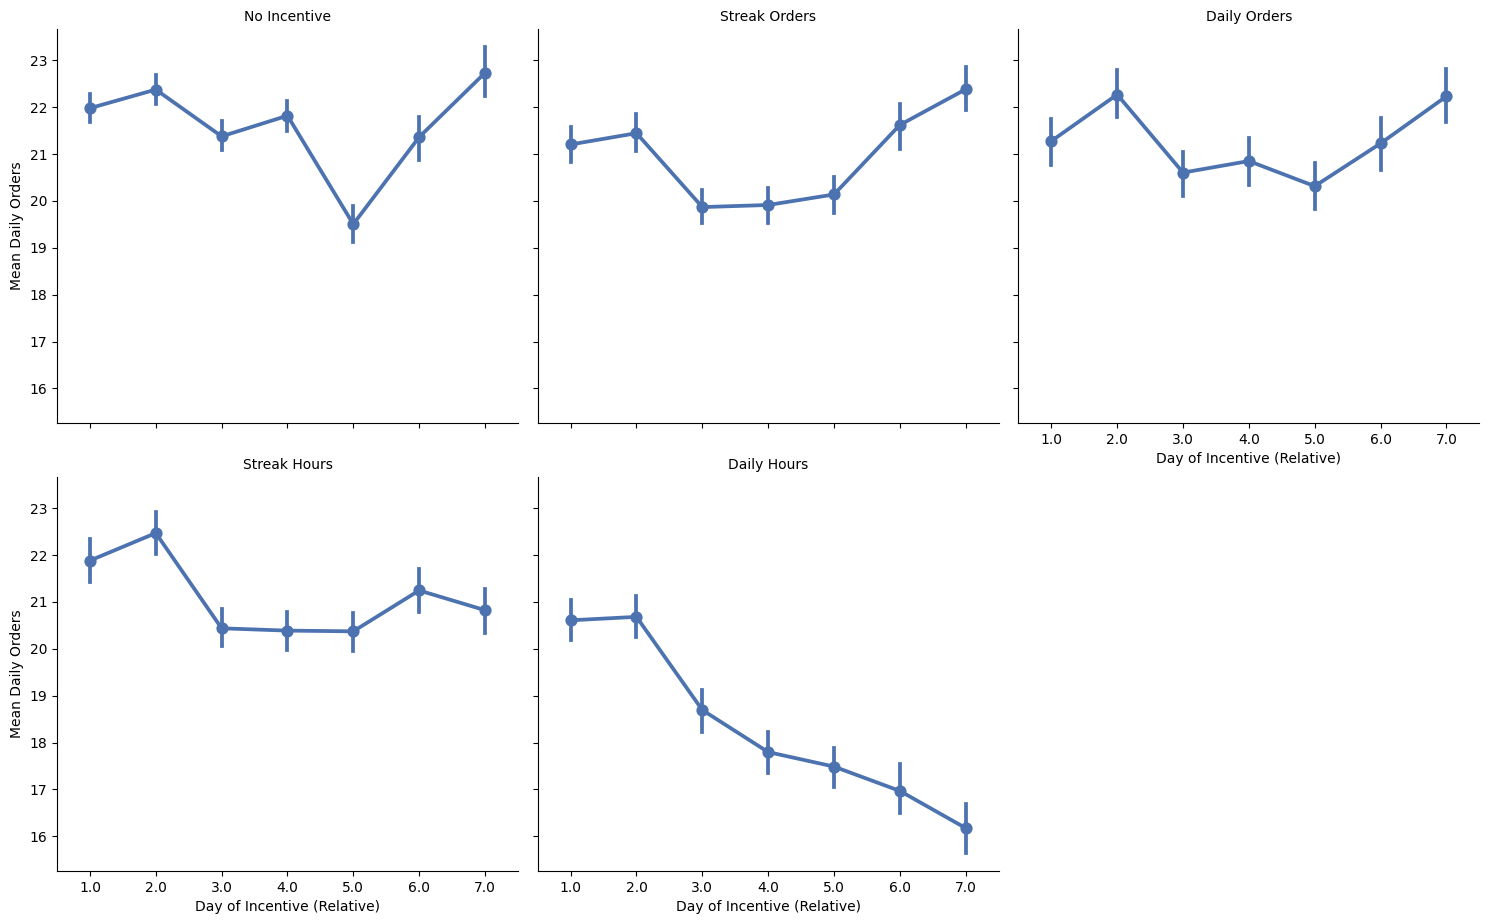

In [19]:
#plot bar charts of orders completed for each incentive across each week 
plt.figure(figsize=(14, 8))

# Using pointplot to show the "effort trajectory"
g = sns.catplot(
    data=driver_summary_grouped, 
    x='day_of_incentive', 
    y='orders_completed', 
    col='Incentive', 
    kind='point',      # Line with dots for each day
    col_wrap=3, 
    sharey=True,       # Keeps Y-axis same across plots for fair comparison
    color="#4C72B0"
)

g.set_axis_labels("Day of Incentive (Relative)", "Mean Daily Orders")
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.9)
# g.fig.suptitle('Incentive Strength: Effort Trajectory from Day 1 to Day 7')

plt.show()


<Figure size 1400x800 with 0 Axes>

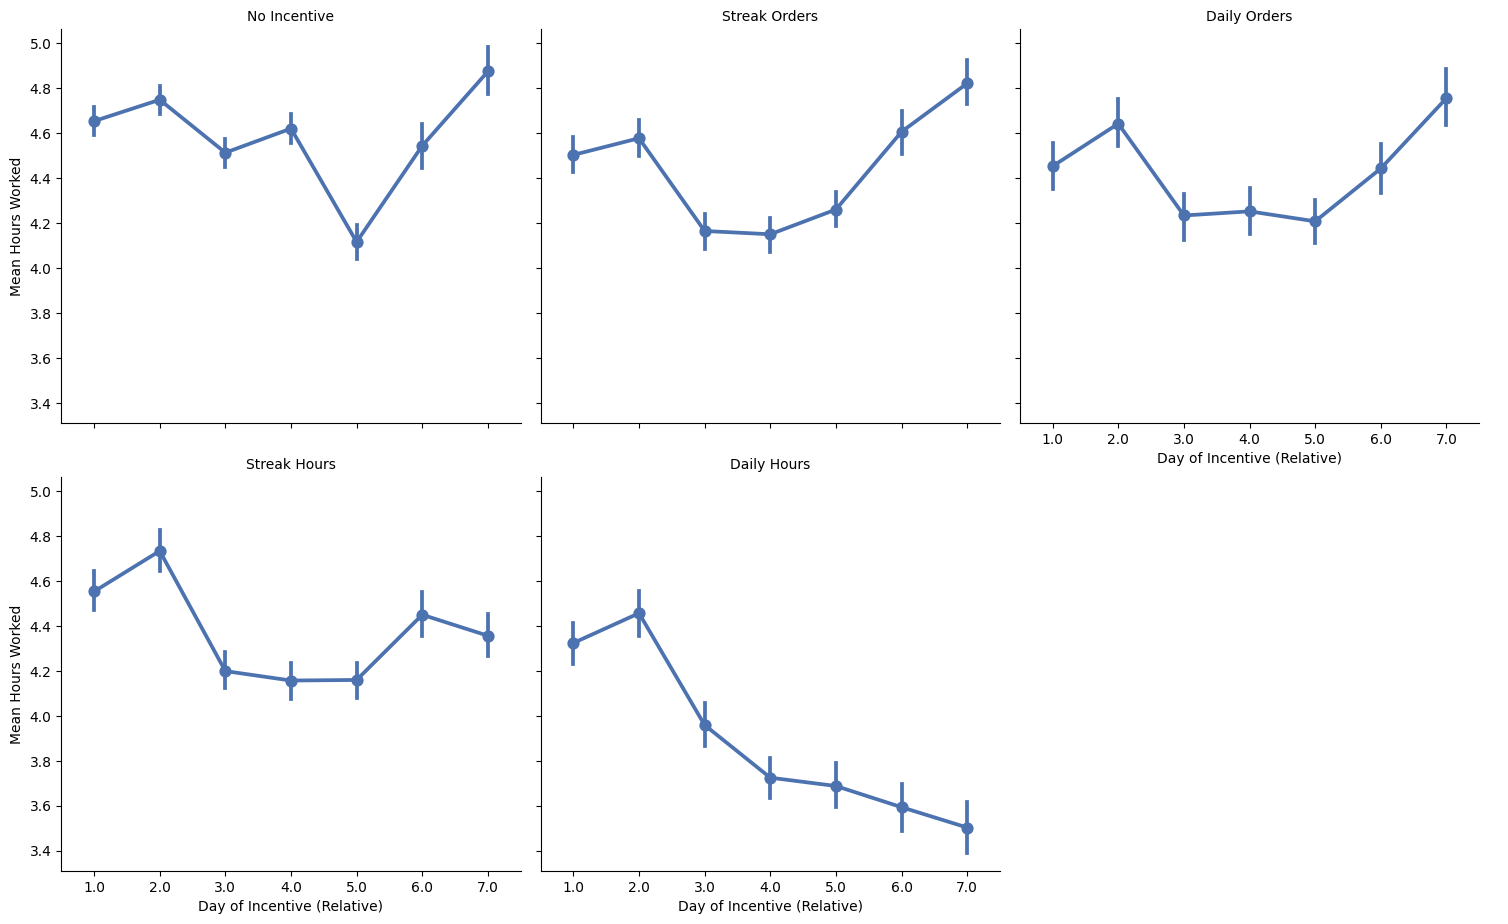

In [20]:
#plot bar charts of orders completed for each incentive across each week 
plt.figure(figsize=(14, 8))

# Using pointplot to show the "effort trajectory"
g = sns.catplot(
    data=driver_summary_grouped, 
    x='day_of_incentive', 
    y='hours_worked', 
    col='Incentive', 
    kind='point',      # Line with dots for each day
    col_wrap=3, 
    sharey=True,       # Keeps Y-axis same across plots for fair comparison
    color="#4C72B0"
)

g.set_axis_labels("Day of Incentive (Relative)", "Mean Hours Worked")
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.9)
# g.fig.suptitle('Incentive Strength: Effort Trajectory from Day 1 to Day 7')

plt.show()

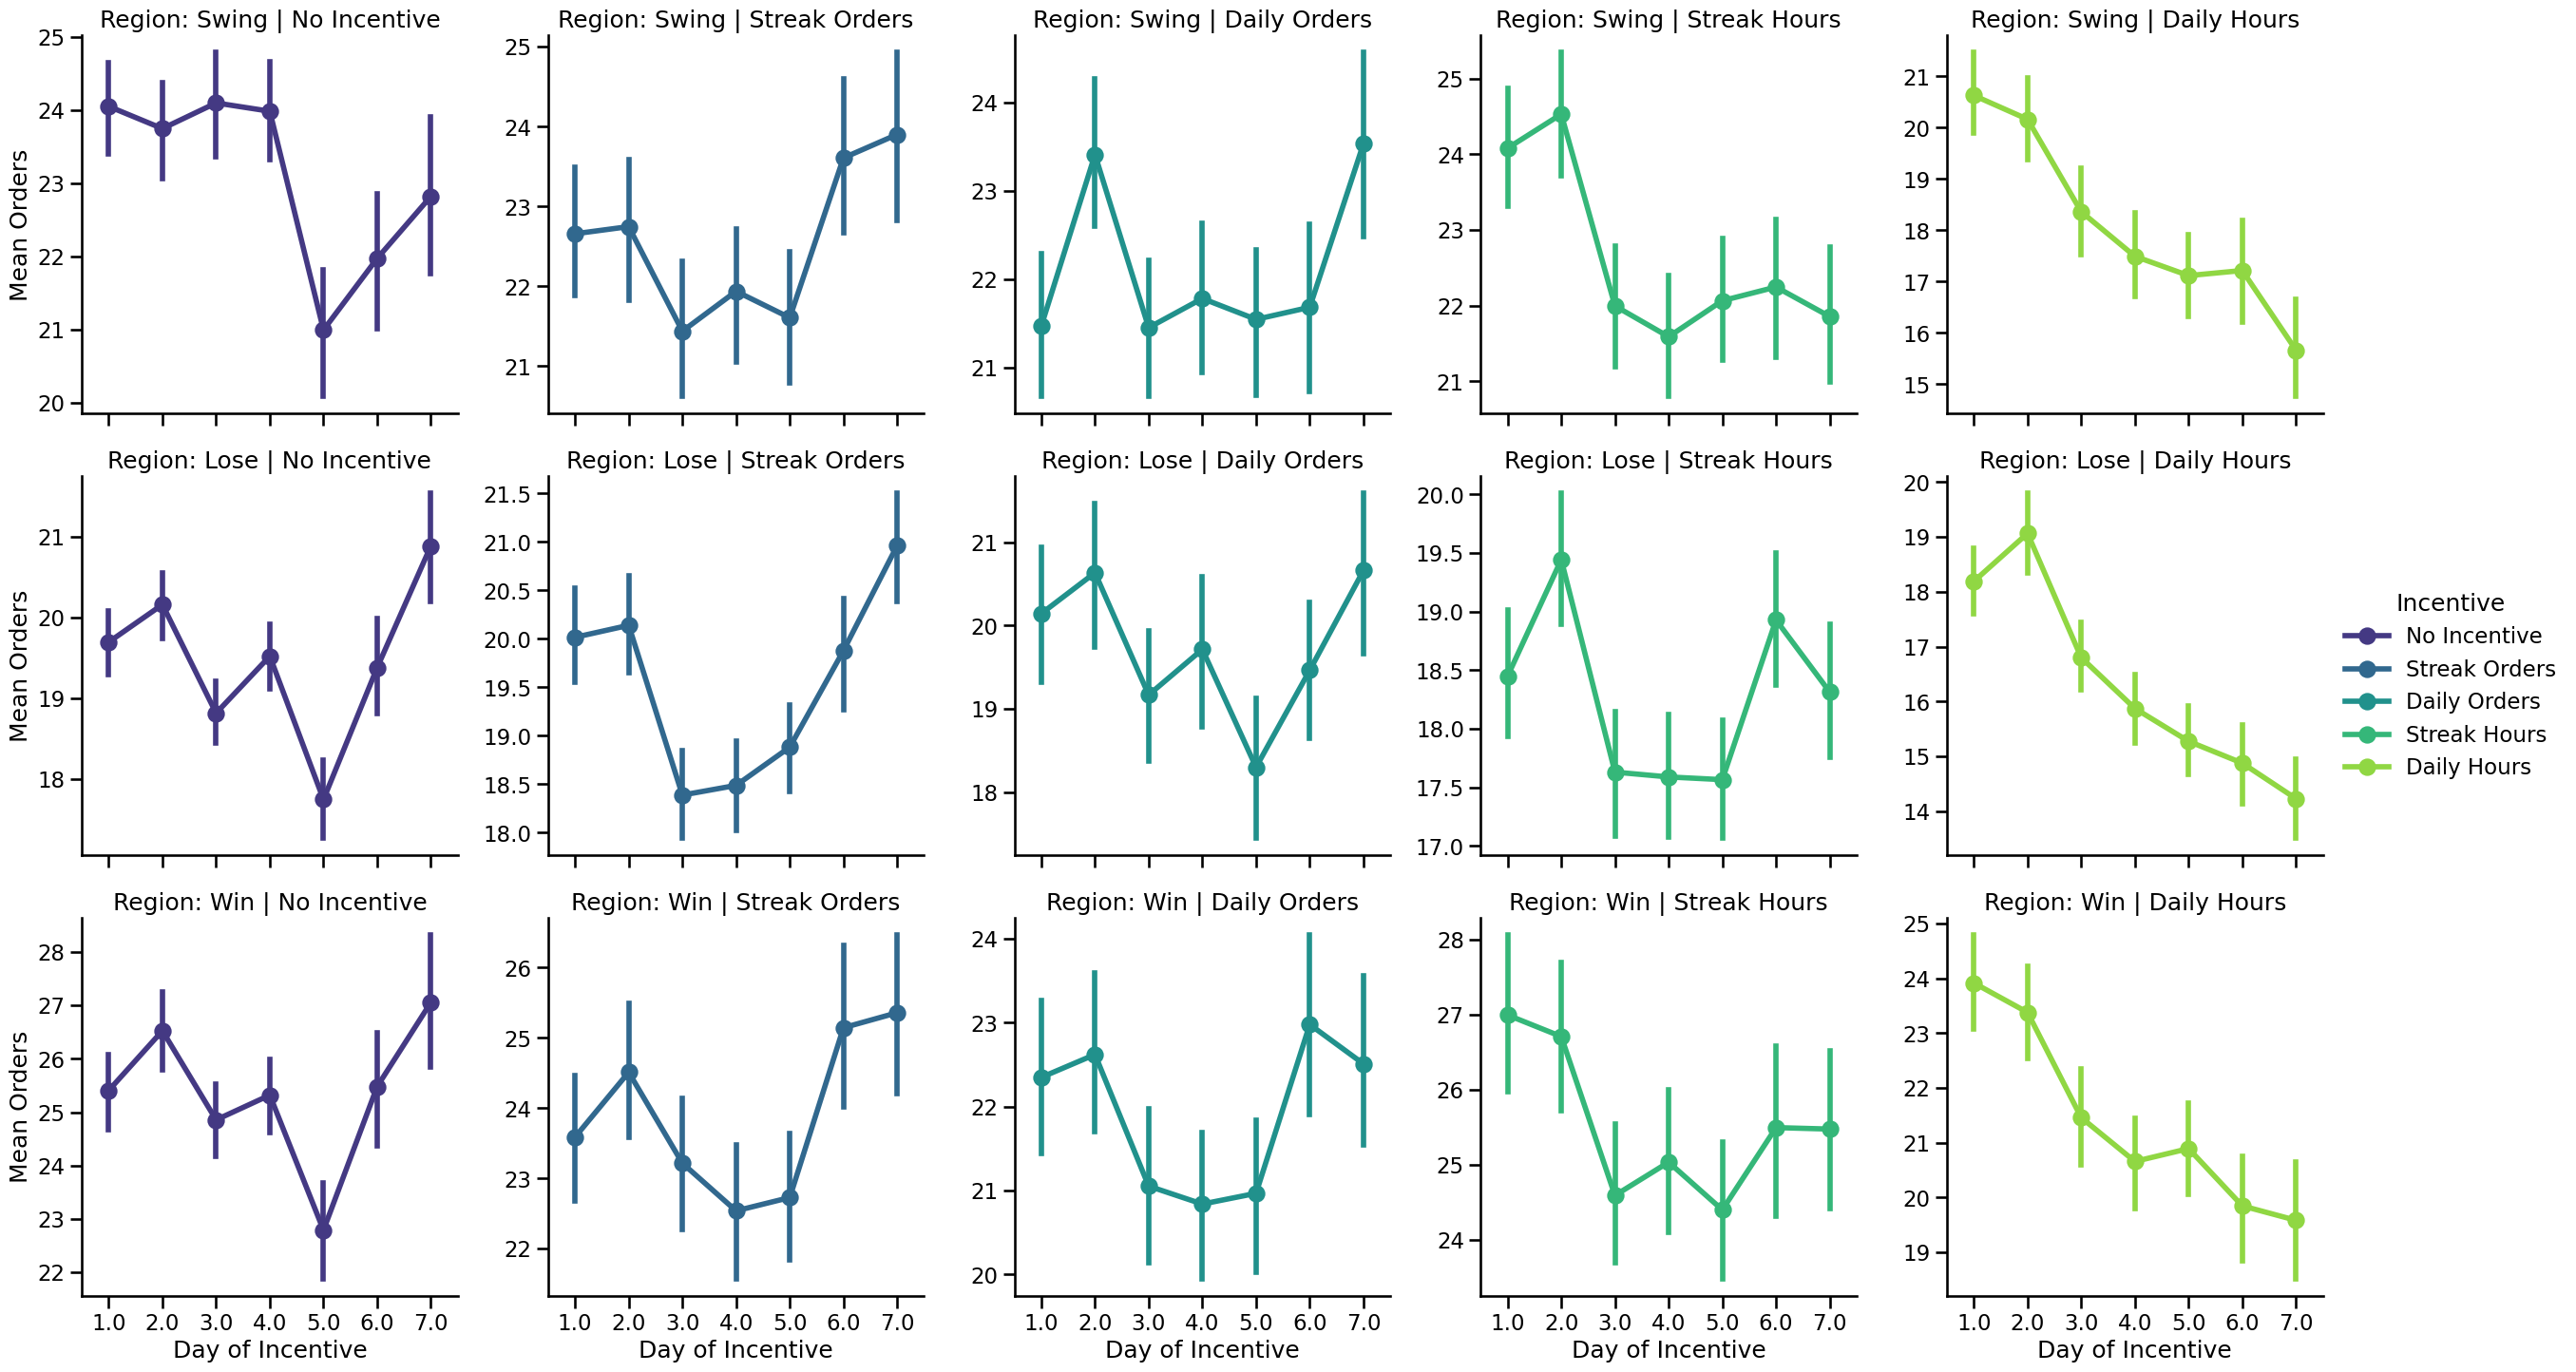

In [21]:
sns.set_context("talk") #makes graphs more readable
g = sns.catplot(
    data=driver_summary_grouped,
    x='day_of_incentive',
    y='orders_completed',
    col='Incentive', 
    row='Status',    # Each region gets its own row
    hue = "Incentive",
    kind='point',
    sharey=False, 
    palette='viridis'
)

g.set_axis_labels("Day of Incentive", "Mean Orders")
g.set_titles("Region: {row_name} | {col_name}")
plt.subplots_adjust(top=0.95)
# g.fig.suptitle('Incentive Trajectory Comparison Across Regions', fontsize=16)

plt.show()

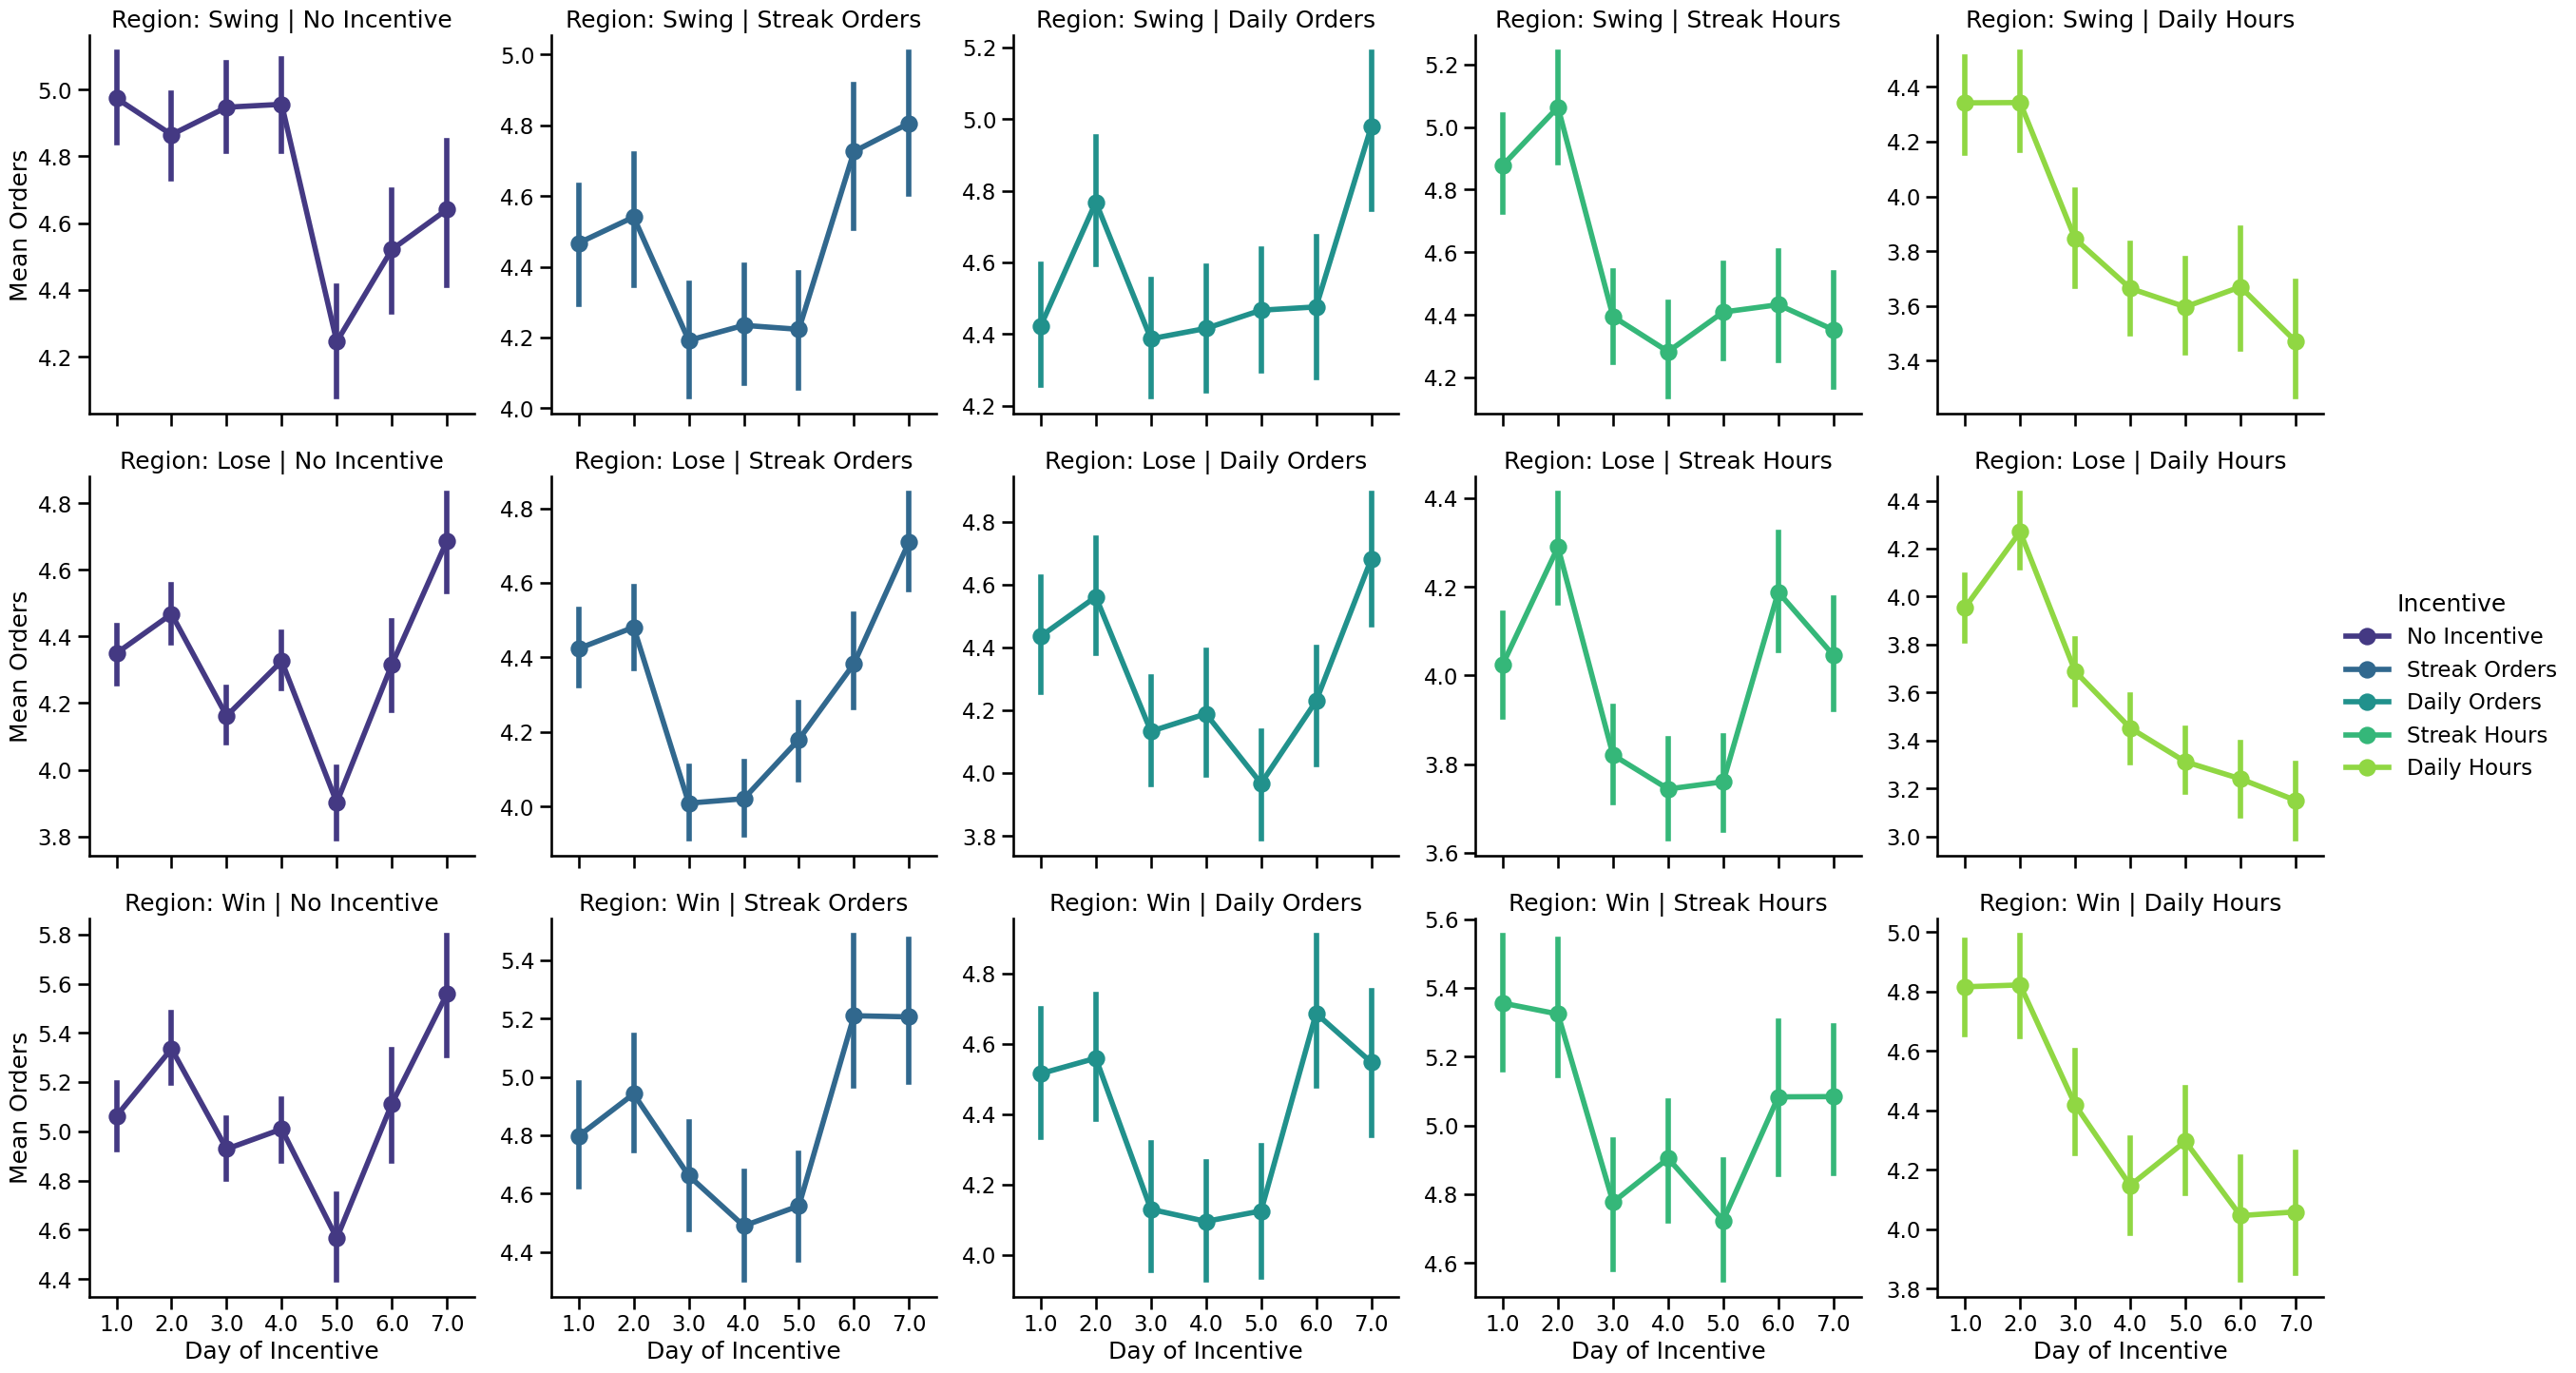

In [22]:
sns.set_context("talk") #makes graphs more readable
g = sns.catplot(
    data=driver_summary_grouped,
    x='day_of_incentive',
    y='hours_worked',
    col='Incentive', 
    row='Status',    # Each region gets its own row
    hue = "Incentive",
    kind='point',
    sharey=False, 
    palette='viridis'
)

g.set_axis_labels("Day of Incentive", "Mean Orders")
g.set_titles("Region: {row_name} | {col_name}")
plt.subplots_adjust(top=0.95)
# g.fig.suptitle('Incentive Trajectory Comparison Across Regions', fontsize=16)

plt.show()

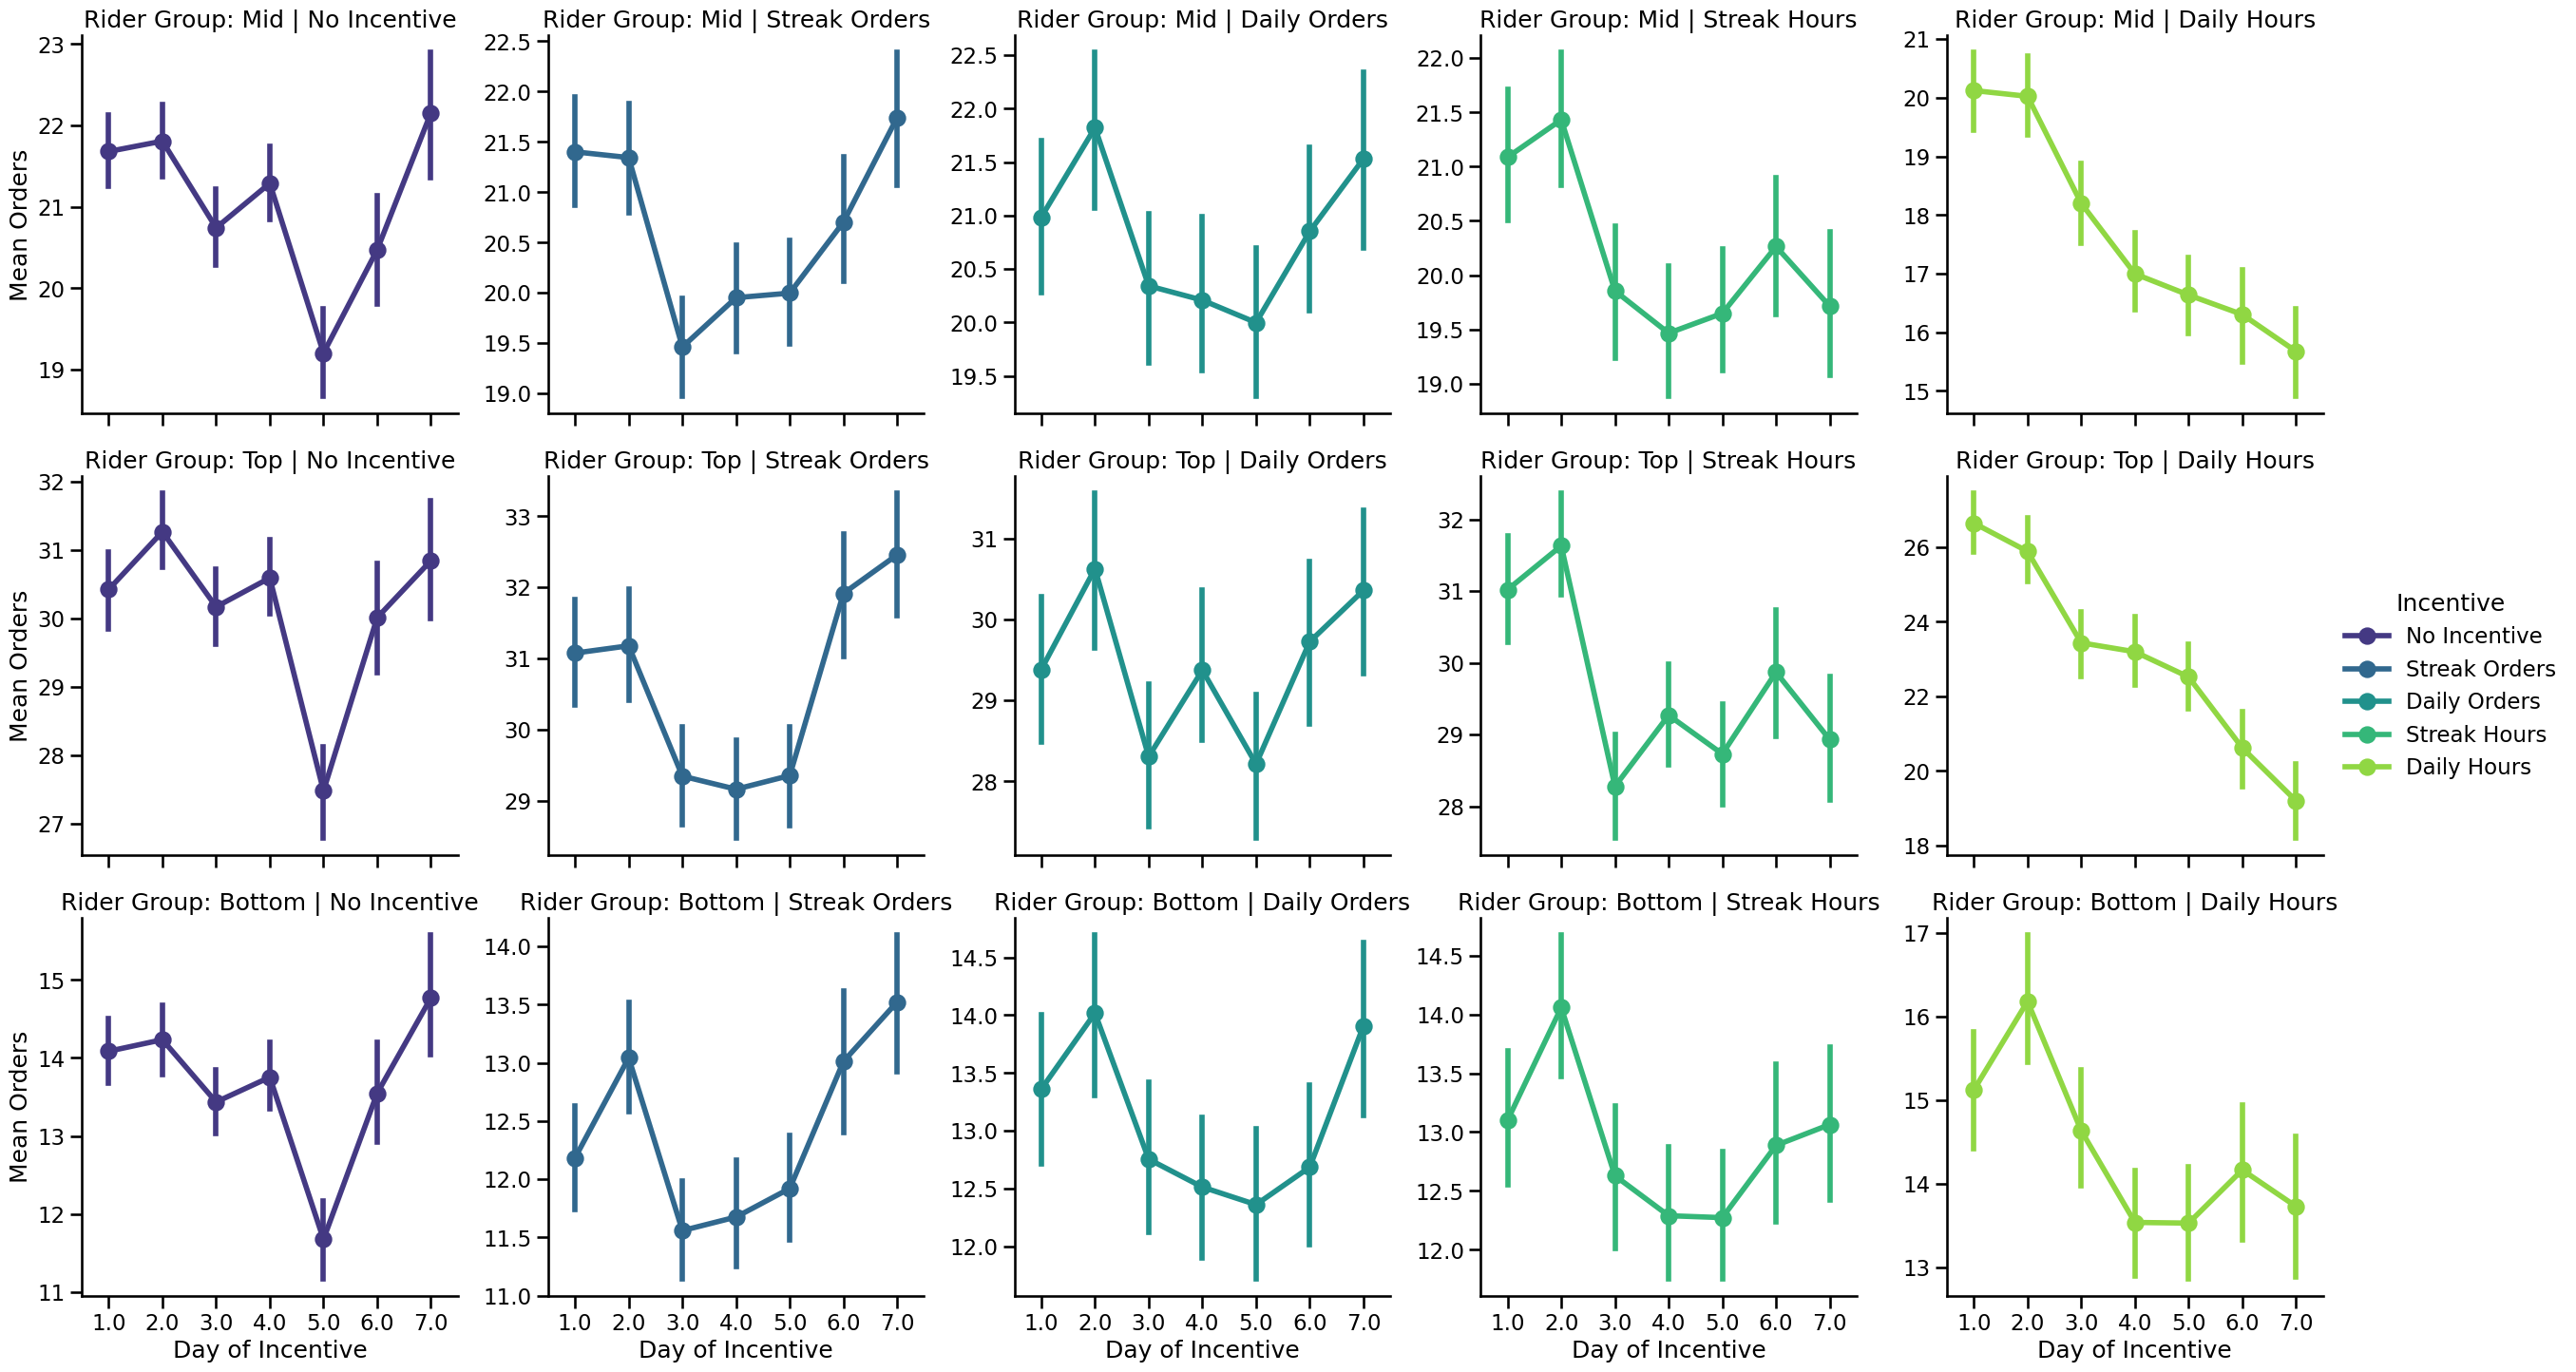

In [23]:
sns.set_context("talk") #makes graphs more readable

g = sns.catplot(
    data=driver_summary_grouped,
    x='day_of_incentive',
    y='orders_completed',
    col='Incentive', 
    row='Rider Group',    # Each region gets its own row
    hue = "Incentive",
    kind='point',
    sharey=False, 
    palette='viridis'
)

g.set_axis_labels("Day of Incentive", "Mean Orders")
g.set_titles("Rider Group: {row_name} | {col_name}")
plt.subplots_adjust(top=0.95)
# g.fig.suptitle('Incentive Trajectory Comparison Across Regions', fontsize=16)

plt.show()

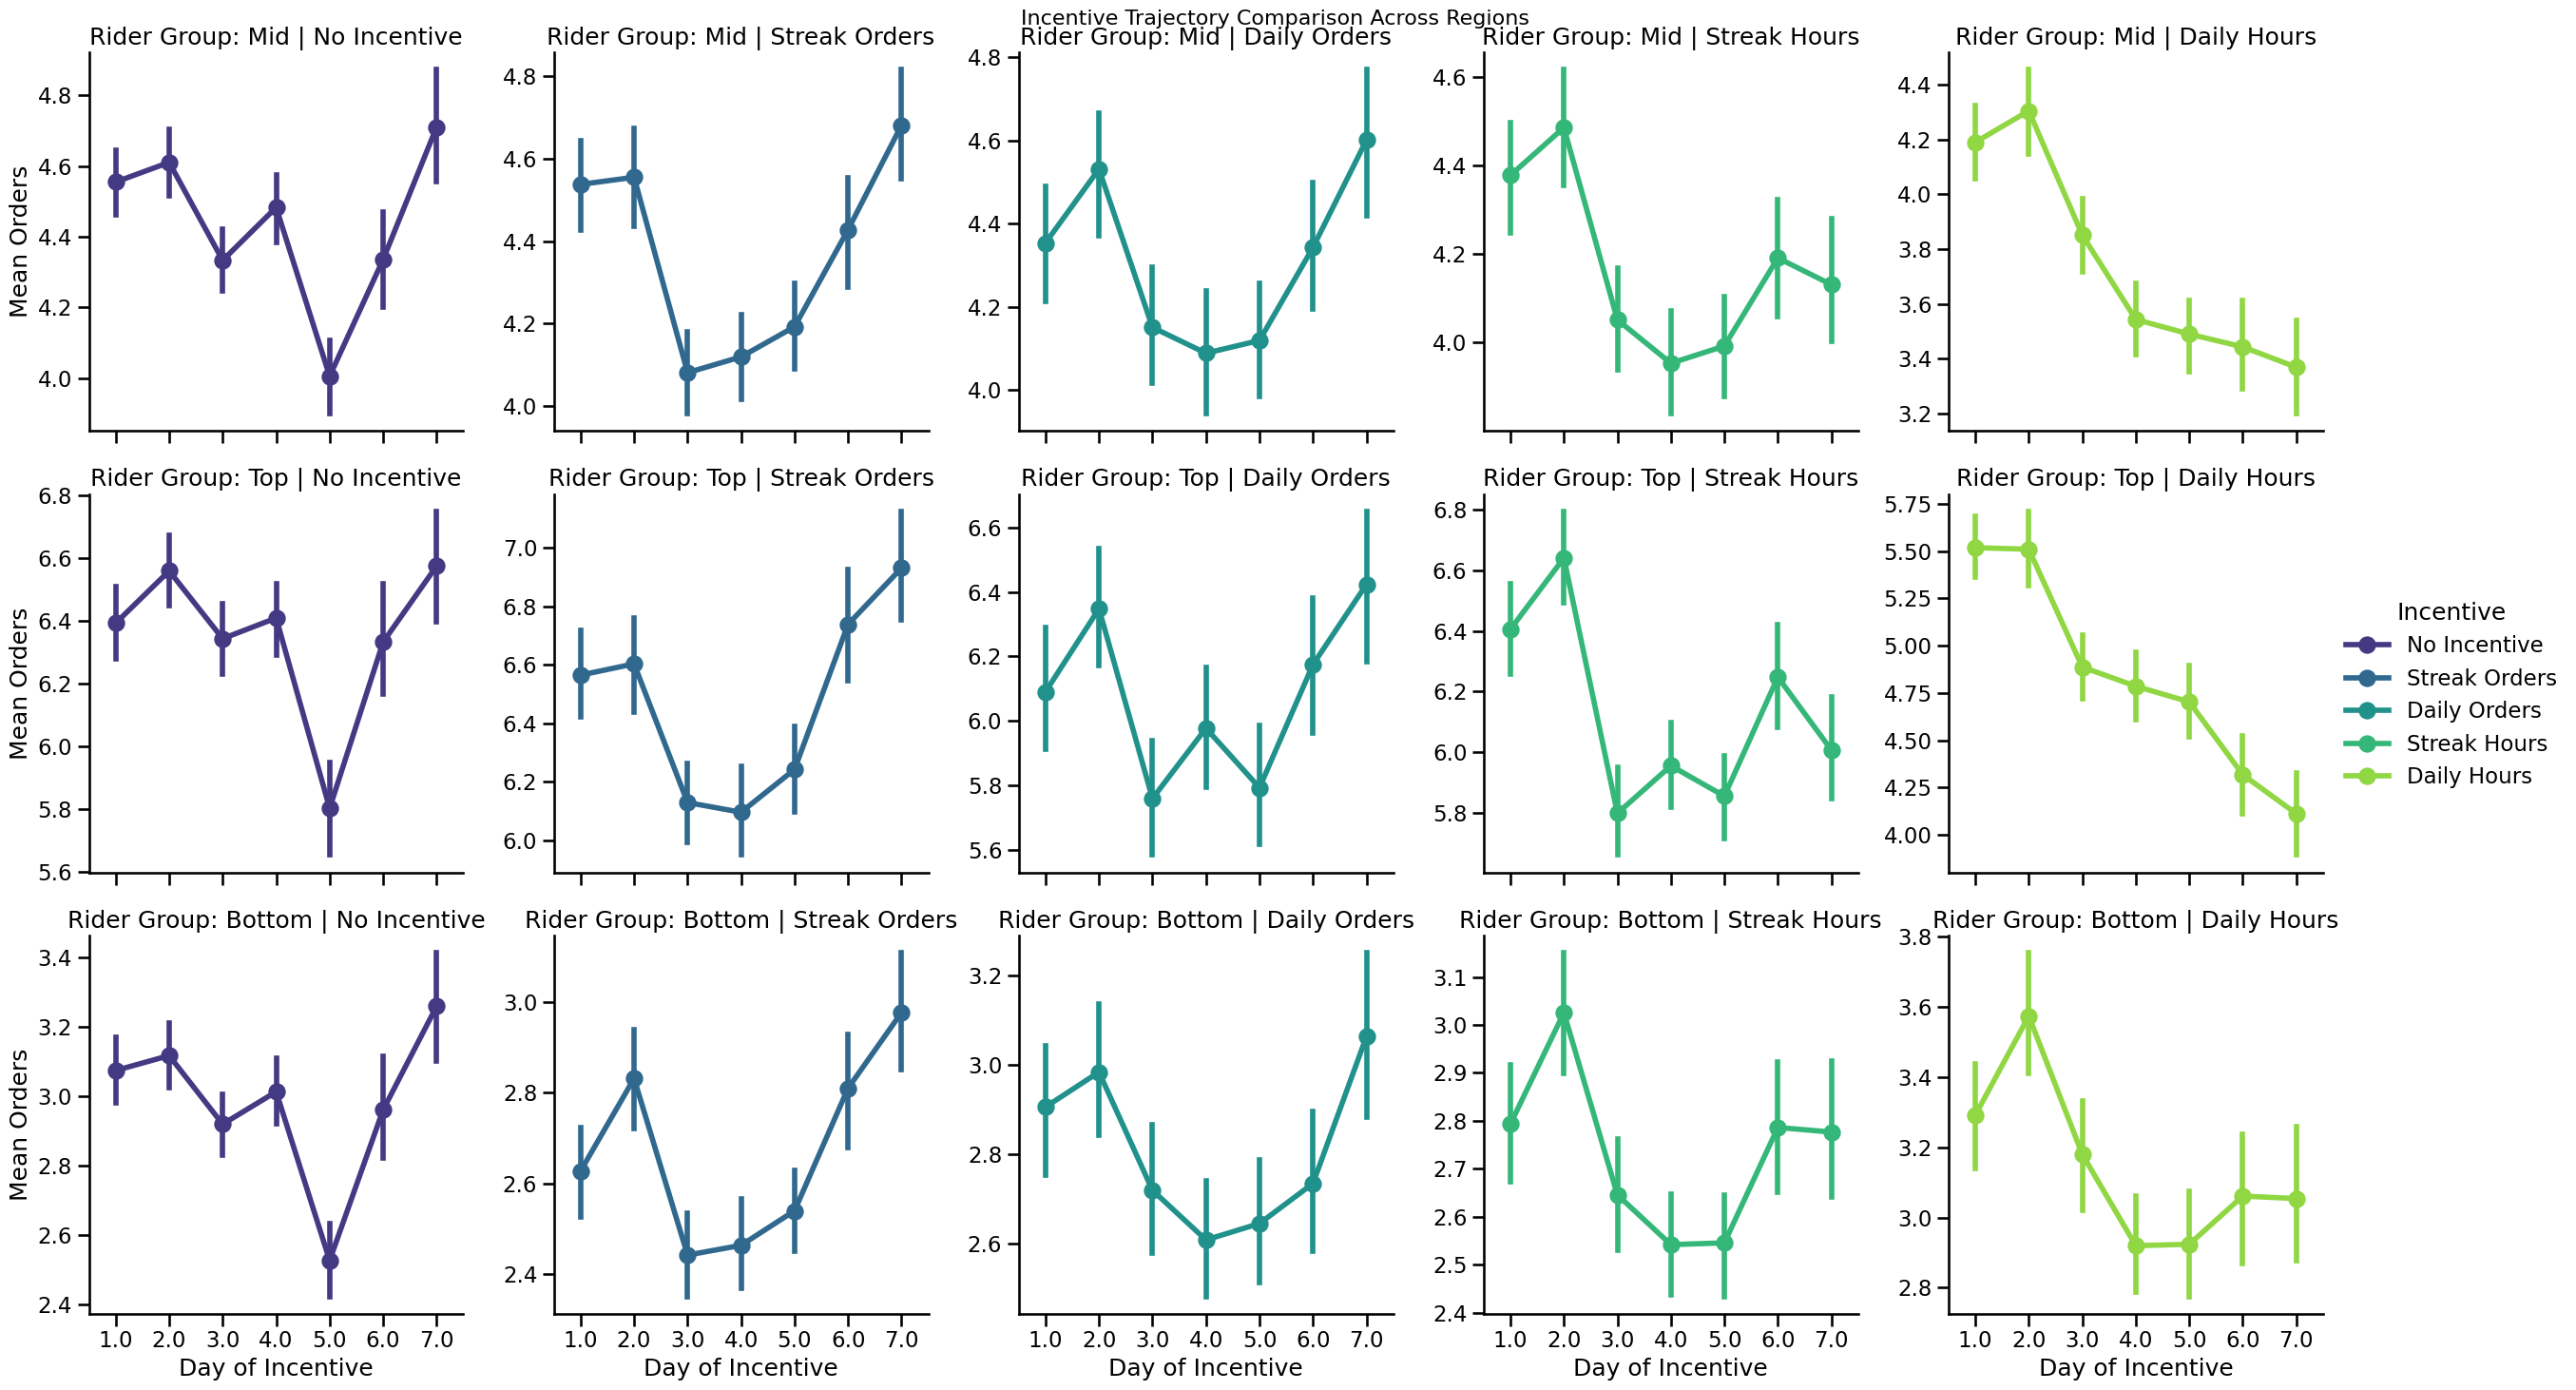

In [24]:
sns.set_context("talk") #makes graphs more readable

g = sns.catplot(
    data=driver_summary_grouped,
    x='day_of_incentive',
    y='hours_worked',
    col='Incentive', 
    row='Rider Group',    # Each region gets its own row
    hue = "Incentive",
    kind='point',
    sharey=False, 
    palette='viridis'
)

g.set_axis_labels("Day of Incentive", "Mean Orders")
g.set_titles("Rider Group: {row_name} | {col_name}")
plt.subplots_adjust(top=0.95)
g.fig.suptitle('Incentive Trajectory Comparison Across Regions', fontsize=16)

plt.show()

In [25]:
driver_summary_grouped['Incentive'].unique()

array(['No Incentive', 'Streak Orders', 'Daily Orders', 'Streak Hours',
       'Daily Hours'], dtype=object)

In [26]:
#with previous days included in the graph 
df = driver_summary_grouped.sort_values(['driver_id', 'date'])

#the grab 'orders_completed' from 1 and 2 days ago 
df['orders_minus_1'] = df.groupby('driver_id')['orders_completed'].shift(1)
df['orders_minus_2'] = df.groupby('driver_id')['orders_completed'].shift(2)

#get averages per incentive
driver_summary_grouped_prev_days = df.groupby(['Incentive', 'day_of_incentive']).agg(
    day_0_to_6=('orders_completed', 'mean'),
    day_minus_1=('orders_minus_1', 'mean'),
    day_minus_2=('orders_minus_2', 'mean')
).reset_index()

#manually build single column for day and single column for accumulated orders 
starts = driver_summary_grouped_prev_days[driver_summary_grouped_prev_days['day_of_incentive'] == 1].copy()

plot_ready = []
for _, row in starts.iterrows():
    plot_ready.append({'Incentive': row['Incentive'], 'day': -2, 'orders': row['day_minus_2']})
    plot_ready.append({'Incentive': row['Incentive'], 'day': -1, 'orders': row['day_minus_1']})

# Add the rest of the normal week (Days 1-6)
normal_week = driver_summary_grouped_prev_days[(driver_summary_grouped_prev_days['day_of_incentive'] >= 1) & 
                                     (driver_summary_grouped_prev_days['day_of_incentive'] <= 6)]

for _, row in normal_week.iterrows():
    plot_ready.append({'Incentive': row['Incentive'], 'day': row['day_of_incentive'], 'orders': row['day_0_to_6']})

df_final_plot = pd.DataFrame(plot_ready)

In [27]:
df

,driver_id,date,region,Incentive,Status,day_of_incentive,Rider Group,orders_completed,acceptance_rate,hours_worked,total_wage,avg_time_per_order_sec,avg_drop_distance,closest_drop_distance,furthest_drop_distance,avg_rain,avg_basket_size,orders_minus_1,orders_minus_2
0,LMD00BZBZ,2025-07-10,SURIN,No Incentive,Swing,1.0,Mid,41,0.953488,8.924722,649.42,783.581395,3057.046512,298.0,6895.0,0.00,159.917442,NaN,NaN
1,LMD00BZBZ,2025-07-11,SURIN,No Incentive,Swing,2.0,Mid,34,0.871795,8.221389,589.93,848.410256,2863.666667,442.0,6330.0,0.00,130.217436,41.0,NaN
2,LMD00BZBZ,2025-07-12,SURIN,No Incentive,Swing,3.0,Mid,30,0.810811,7.131111,572.37,915.270270,3307.972973,244.0,7419.0,0.33,112.129730,34.0,41.0
3,LMD00BZBZ,2025-07-13,SURIN,No Incentive,Swing,4.0,Mid,27,1.000000,6.377778,415.60,850.370370,2944.074074,290.0,7090.0,0.00,106.174074,30.0,34.0
4,LMD00BZBZ,2025-07-14,SURIN,Streak Orders,Swing,1.0,Mid,12,1.000000,2.602778,202.76,780.833333,3685.000000,329.0,5455.0,0.76,129.683333,27.0,30.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153614,LMDZZVYF8,2025-08-24,PHAYAO,Daily Orders,Swing,2.0,Mid,22,1.000000,4.407222,348.60,721.181818,2820.363636,563.0,5606.0,0.61,148.709091,18.0,17.0
153615,LMDZZVYF8,2025-08-25,PHAYAO,Daily Orders,Swing,3.0,Mid,15,1.000000,4.213611,231.00,1011.266667,2894.400000,224.0,6360.0,0.00,97.466667,22.0,18.0
153616,LMDZZVYF8,2025-08-26,PHAYAO,Daily Orders,Swing,4.0,Mid,16,1.000000,3.030833,232.00,681.937500,1997.125000,527.0,4339.0,3.99,117.678125,15.0,22.0
153617,LMDZZVYF8,2025-08-27,PHAYAO,Daily Orders,Swing,5.0,Mid,16,1.000000,2.665000,266.20,599.625000,3105.375000,594.0,6267.0,0.41,128.148750,16.0,15.0


In [28]:
df_final_plot

,Incentive,day,orders
0,Daily Hours,-2.0,22.216159
1,Daily Hours,-1.0,22.588568
2,Daily Orders,-2.0,21.821682
3,Daily Orders,-1.0,21.331037
4,No Incentive,-2.0,20.405278
5,No Incentive,-1.0,20.406615
6,Streak Hours,-2.0,20.963703
7,Streak Hours,-1.0,21.076831
8,Streak Orders,-2.0,21.272806
9,Streak Orders,-1.0,21.290993


<Figure size 1400x1000 with 0 Axes>

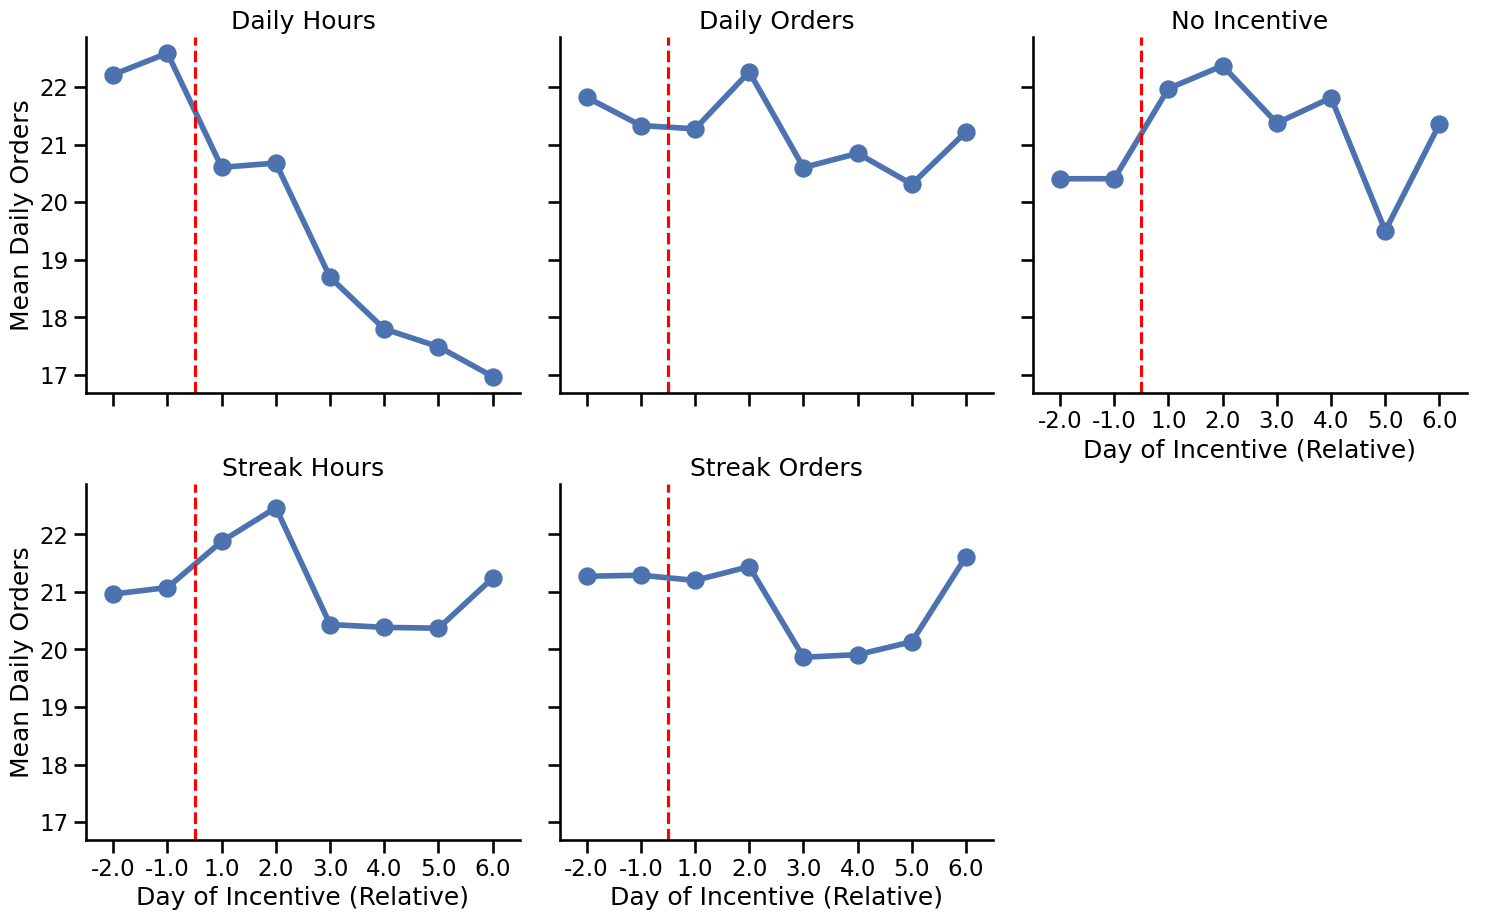

In [29]:
#plot bar charts of orders completed for each incentive across each week 
plt.figure(figsize=(14, 10))

# Using pointplot to show the "effort trajectory"
g = sns.catplot(
    data=df_final_plot, 
    x='day', 
    y='orders', 
    col='Incentive', 
    kind='point',      # Line with dots for each day
    col_wrap=3, 
    sharey=True,       # Keeps Y-axis same across plots for fair comparison
    color="#4C72B0"
)

for ax in g.axes.flat:
    ax.set_ylabel("Mean Daily Orders") # Sets the title for every plot
    ax.set_xlabel("Day of Incentive (Relative)") # Manually set the X-label
    # ax.tick_params(labelleft=True, labelbottom=True) # Force BOTH axes labels to show
    ax.axvline(x=1.5, color='red', linestyle='--', label='Start') #sets vertical line showing where incentive actually began


# # vertical line showing where the incentive actually began
# for ax in g.axes.flat:
#     ax.axvline(x=1.5, color='red', linestyle='--', label='Start')

g.set_axis_labels("Day of Incentive (Relative)", "Mean Daily Orders")
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.9)
# g.fig.suptitle('Incentive Strength: Effort Trajectory from Day 1 to Day 7')

plt.show()


In [30]:
# Create a dummy variable for "Is it Day 1?"
driver_summary_grouped['is_day_1'] = (driver_summary_grouped['day_of_incentive'] == 1).astype(int)

# Mixed Effects Model
# Formula: orders ~ is_day_1 * Incentive
# This tests: Is the Day 1 'boost' different for Streaks vs. Daily?
# Force 'No Incentive' to be the baseline
model_shock = smf.mixedlm(
    "orders_completed ~ is_day_1 * C(Incentive, Treatment(reference='No Incentive'))", 
    data=driver_summary_grouped, 
    groups="driver_id"
)

shock_results = model_shock.fit()
print(shock_results.summary())
print(shock_results.summary().tables[1].to_latex())

                                         Mixed Linear Model Regression Results
Model:                                MixedLM                    Dependent Variable:                    orders_completed
No. Observations:                     153619                     Method:                                REML            
No. Groups:                           7471                       Scale:                                 94.1237         
Min. group size:                      1                          Log-Likelihood:                        -578081.5659    
Max. group size:                      37                         Converged:                             Yes             
Mean group size:                      20.6                                                                              
------------------------------------------------------------------------------------------------------------------------
                                                                          

In [31]:
#to see if drivers productivity spikes on day 1 and then falls throughout the week
driver_summary_grouped['day_sq'] = driver_summary_grouped['day_of_incentive']**2

for incentive in driver_summary_grouped['Incentive'].unique():
    print(f"\n--- Decay Analysis for {incentive} ---")
    subset = driver_summary_grouped[driver_summary_grouped['Incentive'] == incentive]
    
    # Logic: orders ~ day + day_sq
    model = smf.mixedlm("orders_completed ~ day_of_incentive + day_sq", 
                        data=subset, 
                        groups=subset["driver_id"])
    
    result = model.fit()
    print(result.summary().tables[1])
    print(result.summary().tables[1].to_latex())


--- Decay Analysis for No Incentive ---
                    Coef. Std.Err.       z  P>|z|  [0.025  0.975]
Intercept          21.887    0.222  98.788  0.000  21.453  22.321
day_of_incentive   -0.870    0.103  -8.483  0.000  -1.071  -0.669
day_sq              0.093    0.013   7.018  0.000   0.067   0.119
Group Var         120.864    0.291                               
\begin{tabular}{lllllll}
\toprule
 & Coef. & Std.Err. & z & P>|z| & [0.025 & 0.975] \\
\midrule
Intercept & 21.887 & 0.222 & 98.788 & 0.000 & 21.453 & 22.321 \\
day_of_incentive & -0.870 & 0.103 & -8.483 & 0.000 & -1.071 & -0.669 \\
day_sq & 0.093 & 0.013 & 7.018 & 0.000 & 0.067 & 0.119 \\
Group Var & 120.864 & 0.291 &  &  &  &  \\
\bottomrule
\end{tabular}


--- Decay Analysis for Streak Orders ---
                    Coef. Std.Err.        z  P>|z|  [0.025  0.975]
Intercept          21.101    0.259   81.555  0.000  20.594  21.608
day_of_incentive   -1.731    0.105  -16.412  0.000  -1.938  -1.524
day_sq              0.231

In [32]:
# Ensure driver_tier is treated as a categorical variable
for incentive in driver_summary_grouped['Incentive'].unique():
    print(f"\n--- Tiered Analysis for {incentive} ---")
    subset = driver_summary_grouped[driver_summary_grouped['Incentive'] == incentive]
    
    # Formula logic: 
    # We interact Driver Tier with both Day and Day_sq
    # This shows if the 'slope' and the 'curve' vary by Tier
    formula = "orders_completed ~ C(Q('Rider Group')) * (day_of_incentive + day_sq)"
    
    model = smf.mixedlm(formula, data=subset, groups=subset["driver_id"])
    result = model.fit()
    
    # We focus on the interaction terms
    print(result.summary().tables[1])
    print(result.summary().tables[1].to_latex())


--- Tiered Analysis for No Incentive ---
                                              Coef. Std.Err.       z  P>|z|  \
Intercept                                    17.140    0.352  48.726  0.000   
C(Q('Rider Group'))[T.Mid]                    5.778    0.456  12.672  0.000   
C(Q('Rider Group'))[T.Top]                   10.662    0.503  21.185  0.000   
day_of_incentive                             -0.886    0.190  -4.670  0.000   
C(Q('Rider Group'))[T.Mid]:day_of_incentive  -0.105    0.252  -0.416  0.677   
C(Q('Rider Group'))[T.Top]:day_of_incentive   0.173    0.265   0.651  0.515   
day_sq                                        0.100    0.025   4.059  0.000   
C(Q('Rider Group'))[T.Mid]:day_sq             0.006    0.033   0.173  0.863   
C(Q('Rider Group'))[T.Top]:day_sq            -0.035    0.034  -1.021  0.307   
Group Var                                    80.763    0.215                  

                                             [0.025  0.975]  
Intercept                 

In [33]:
driver_summary_grouped["date"] = pd.to_datetime(driver_summary_grouped["date"])

bins = [
    pd.Timestamp.min,
    pd.Timestamp('2025-07-13'),
    pd.Timestamp('2025-07-20'),
    pd.Timestamp('2025-07-27'),
    pd.Timestamp('2025-08-03'),
    pd.Timestamp('2025-08-10'),
    pd.Timestamp('2025-08-15'),
    pd.Timestamp('2025-08-23'),
    pd.Timestamp.max,
]
labels = ['0', '1', '2', '3', '4', '5', '6', '7']


driver_summary_grouped["Week Num"] = pd.cut(driver_summary_grouped["date"], bins=bins, labels=labels)


In [34]:
driver_summary_grouped

,driver_id,date,region,Incentive,Status,day_of_incentive,Rider Group,orders_completed,acceptance_rate,hours_worked,total_wage,avg_time_per_order_sec,avg_drop_distance,closest_drop_distance,furthest_drop_distance,avg_rain,avg_basket_size,is_day_1,day_sq,Week Num
0,LMD00BZBZ,2025-07-10,SURIN,No Incentive,Swing,1.0,Mid,41,0.953488,8.924722,649.42,783.581395,3057.046512,298.0,6895.0,0.00,159.917442,1,1.0,0
1,LMD00BZBZ,2025-07-11,SURIN,No Incentive,Swing,2.0,Mid,34,0.871795,8.221389,589.93,848.410256,2863.666667,442.0,6330.0,0.00,130.217436,0,4.0,0
2,LMD00BZBZ,2025-07-12,SURIN,No Incentive,Swing,3.0,Mid,30,0.810811,7.131111,572.37,915.270270,3307.972973,244.0,7419.0,0.33,112.129730,0,9.0,0
3,LMD00BZBZ,2025-07-13,SURIN,No Incentive,Swing,4.0,Mid,27,1.000000,6.377778,415.60,850.370370,2944.074074,290.0,7090.0,0.00,106.174074,0,16.0,0
4,LMD00BZBZ,2025-07-14,SURIN,Streak Orders,Swing,1.0,Mid,12,1.000000,2.602778,202.76,780.833333,3685.000000,329.0,5455.0,0.76,129.683333,1,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153614,LMDZZVYF8,2025-08-24,PHAYAO,Daily Orders,Swing,2.0,Mid,22,1.000000,4.407222,348.60,721.181818,2820.363636,563.0,5606.0,0.61,148.709091,0,4.0,7
153615,LMDZZVYF8,2025-08-25,PHAYAO,Daily Orders,Swing,3.0,Mid,15,1.000000,4.213611,231.00,1011.266667,2894.400000,224.0,6360.0,0.00,97.466667,0,9.0,7
153616,LMDZZVYF8,2025-08-26,PHAYAO,Daily Orders,Swing,4.0,Mid,16,1.000000,3.030833,232.00,681.937500,1997.125000,527.0,4339.0,3.99,117.678125,0,16.0,7
153617,LMDZZVYF8,2025-08-27,PHAYAO,Daily Orders,Swing,5.0,Mid,16,1.000000,2.665000,266.20,599.625000,3105.375000,594.0,6267.0,0.41,128.148750,0,25.0,7


In [35]:
#statistical test using day of week as the categorical
formula_categorical = """
orders_completed ~ C(day_of_incentive, Treatment(reference=-1)) * C(Incentive, Treatment(reference='No Incentive'))
"""

model_categorical_shock = smf.mixedlm(
    formula_categorical, 
    data=driver_summary_grouped, 
    groups=driver_summary_grouped["driver_id"]
)

cat_shock_results = model_categorical_shock.fit()

# Print summary
print(cat_shock_results.summary())

# To export for your report
print(cat_shock_results.summary().tables[1].to_latex())

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/linalg/_linalg.py:2325: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/linalg/_linalg.py:2325: RuntimeWarning: overflow encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/linalg/_linalg.py:2325: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)


                                                               Mixed Linear Model Regression Results
Model:                                               MixedLM                                  Dependent Variable:                                  orders_completed
No. Observations:                                    153619                                   Method:                                              REML            
No. Groups:                                          7471                                     Scale:                                               93.3283         
Min. group size:                                     1                                        Log-Likelihood:                                      -577467.8661    
Max. group size:                                     37                                       Converged:                                           Yes             
Mean group size:                                     20.6                      

In [38]:
INCENTIVE_COLORS = {
    "Streak Hours":  "#003f7f",
    "Streak Orders": "#8b0000",
    "Daily Hours":   "#6baed6",
    "Daily Orders":  "#fc8d8d",
    "No Incentive":  '#eed202',
}

<Figure size 1400x1000 with 0 Axes>

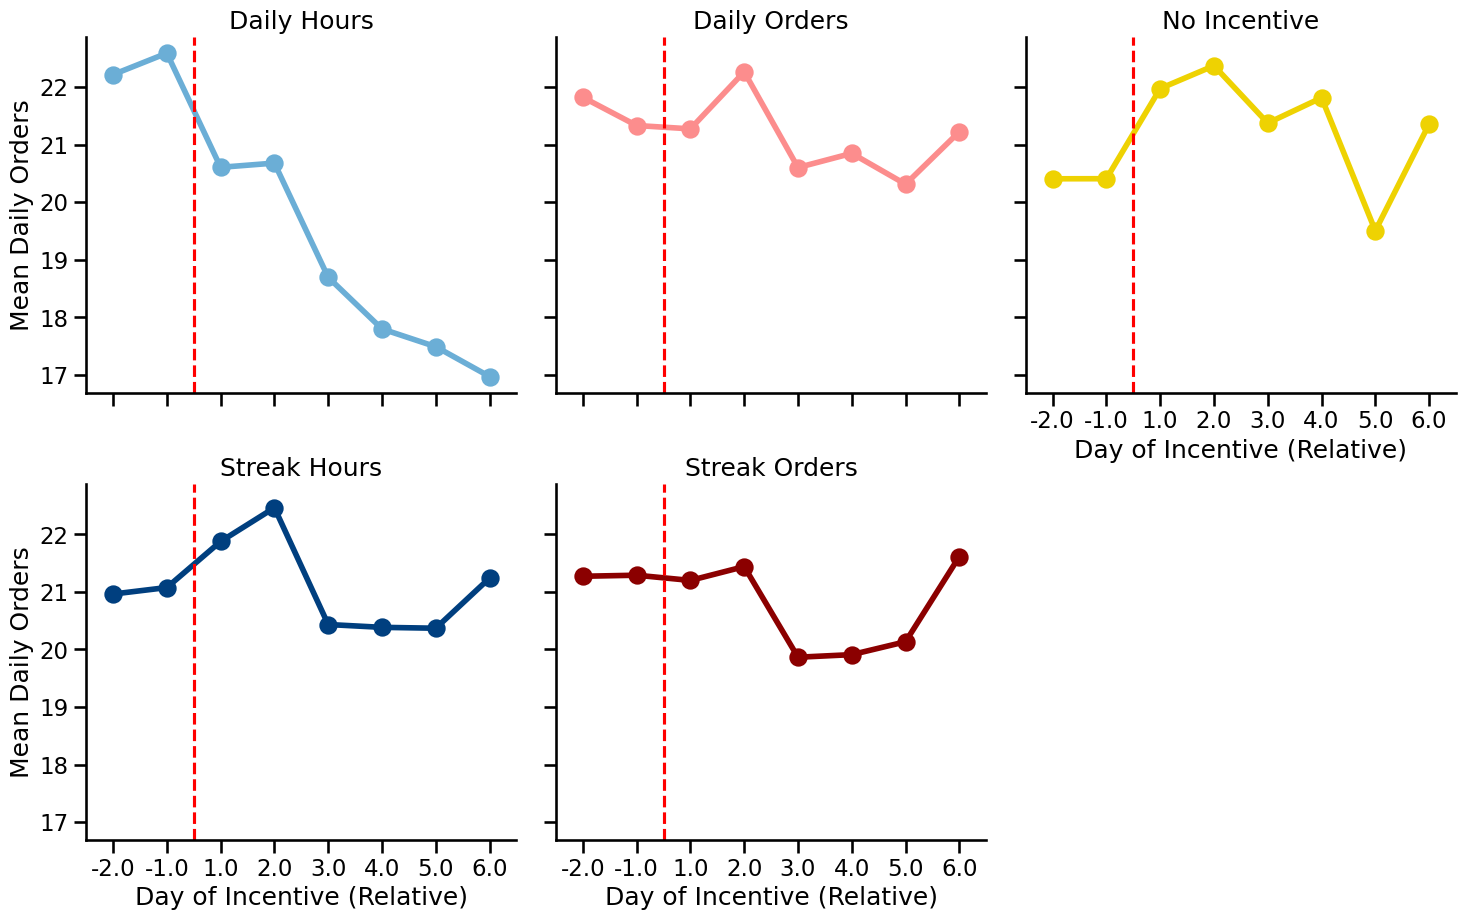

In [39]:
plt.figure(figsize=(14, 10))

g = sns.catplot(
    data=df_final_plot, 
    x='day', 
    y='orders', 
    col='Incentive', 
    kind='point',
    col_wrap=3, 
    sharey=True,
    palette=INCENTIVE_COLORS,  # replaces color="#4C72B0"
    hue='Incentive',           # needed for palette to apply per facet
    legend=False               # hides the redundant legend since col titles already label them
)

for ax in g.axes.flat:
    ax.set_ylabel("Mean Daily Orders")
    ax.set_xlabel("Day of Incentive (Relative)")
    ax.axvline(x=1.5, color='red', linestyle='--', label='Start')

g.set_axis_labels("Day of Incentive (Relative)", "Mean Daily Orders")
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.9)
plt.show()


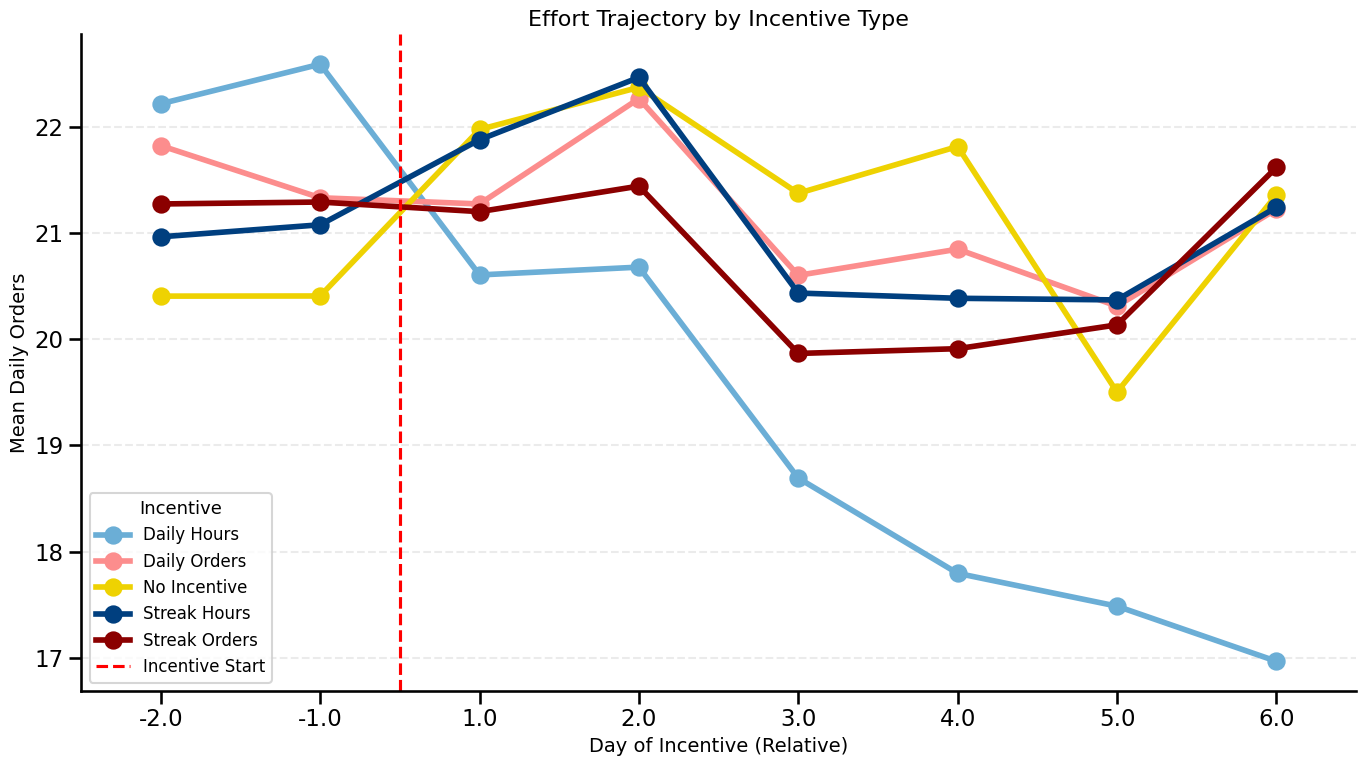

In [40]:

fig, ax = plt.subplots(figsize=(14, 8))

sns.pointplot(
    data=df_final_plot,
    x='day',
    y='orders',
    hue='Incentive',
    palette=INCENTIVE_COLORS,
    markers='o',
    ax=ax
)

ax.axvline(x=1.5, color='red', linestyle='--', label='Incentive Start')
ax.set_xlabel("Day of Incentive (Relative)", fontsize=14)
ax.set_ylabel("Mean Daily Orders", fontsize=14)
ax.set_title("Effort Trajectory by Incentive Type", fontsize=16)
ax.legend(title="Incentive", fontsize=12, title_fontsize=13)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.25)

plt.tight_layout()
plt.show()

In [44]:
#with previous days included in the graph 
df = driver_summary_grouped.sort_values(['driver_id', 'date'])

#the grab 'orders_completed' from 1 and 2 days ago 
df['hours_minus_1'] = df.groupby('driver_id')['hours_worked'].shift(1)
df['hours_minus_2'] = df.groupby('driver_id')['hours_worked'].shift(2)

#get averages per incentive
driver_summary_grouped_prev_days = df.groupby(['Incentive', 'day_of_incentive']).agg(
    day_0_to_6=('hours_worked', 'mean'),
    day_minus_1=('hours_minus_1', 'mean'),
    day_minus_2=('hours_minus_2', 'mean')
).reset_index()

#manually build single column for day and single column for accumulated orders 
starts = driver_summary_grouped_prev_days[driver_summary_grouped_prev_days['day_of_incentive'] == 1].copy()

plot_ready = []
for _, row in starts.iterrows():
    plot_ready.append({'Incentive': row['Incentive'], 'day': -2, 'hours': row['day_minus_2']})
    plot_ready.append({'Incentive': row['Incentive'], 'day': -1, 'hours': row['day_minus_1']})

# Add the rest of the normal week (Days 1-6)
normal_week = driver_summary_grouped_prev_days[(driver_summary_grouped_prev_days['day_of_incentive'] >= 1) & 
                                     (driver_summary_grouped_prev_days['day_of_incentive'] <= 6)]

for _, row in normal_week.iterrows():
    plot_ready.append({'Incentive': row['Incentive'], 'day': row['day_of_incentive'], 'hours': row['day_0_to_6']})

df_final_plot_hours = pd.DataFrame(plot_ready)

In [45]:
df_final_plot_hours

,Incentive,day,hours
0,Daily Hours,-2.0,4.586583
1,Daily Hours,-1.0,4.715848
2,Daily Orders,-2.0,4.540338
3,Daily Orders,-1.0,4.470839
4,No Incentive,-2.0,4.381992
5,No Incentive,-1.0,4.440940
6,Streak Hours,-2.0,4.375611
7,Streak Hours,-1.0,4.420915
8,Streak Orders,-2.0,4.575136
9,Streak Orders,-1.0,4.664105


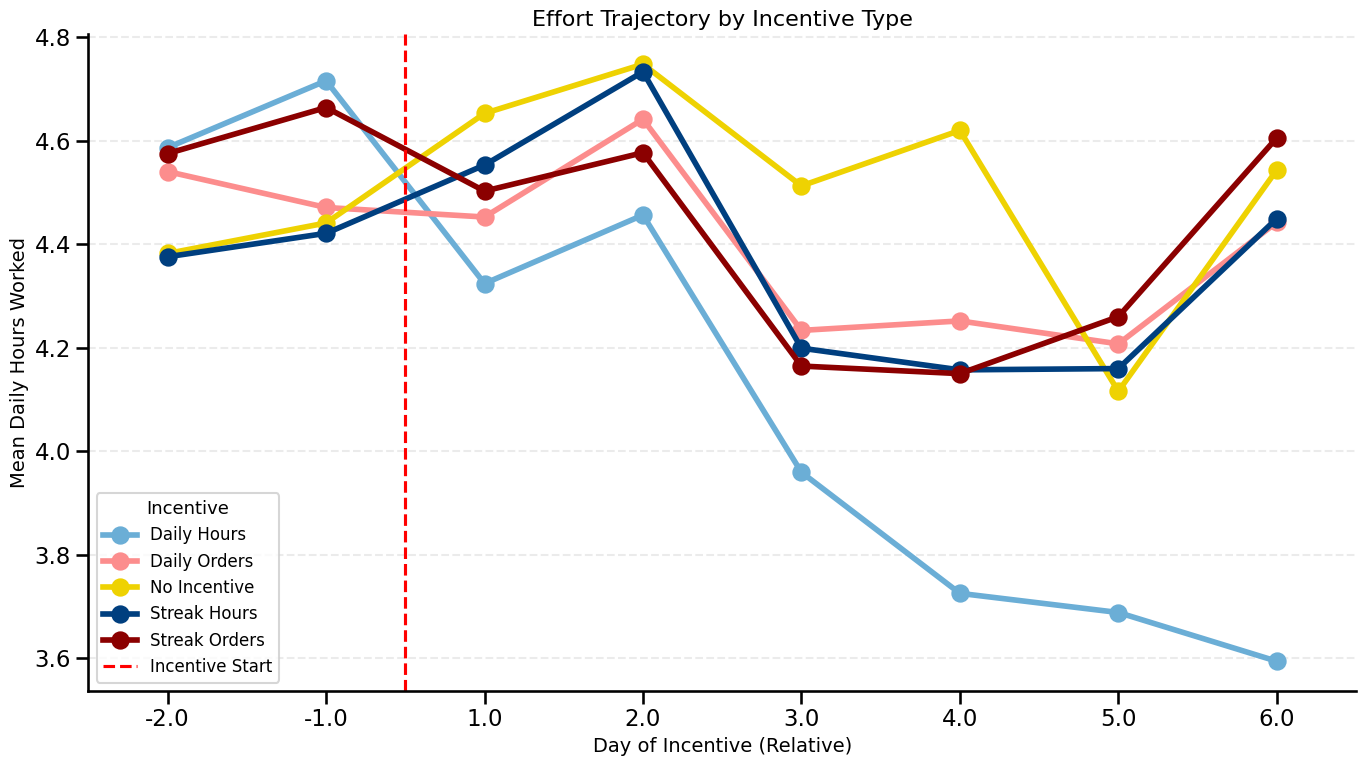

In [47]:

fig, ax = plt.subplots(figsize=(14, 8))

sns.pointplot(
    data=df_final_plot_hours,
    x='day',
    y='hours',
    hue='Incentive',
    palette=INCENTIVE_COLORS,
    markers='o',
    ax=ax
)

ax.axvline(x=1.5, color='red', linestyle='--', label='Incentive Start')
ax.set_xlabel("Day of Incentive (Relative)", fontsize=14)
ax.set_ylabel("Mean Daily Hours Worked", fontsize=14)
ax.set_title("Effort Trajectory by Incentive Type", fontsize=16)
ax.legend(title="Incentive", fontsize=12, title_fontsize=13)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.25)

plt.tight_layout()
plt.show()

<Figure size 1400x1000 with 0 Axes>

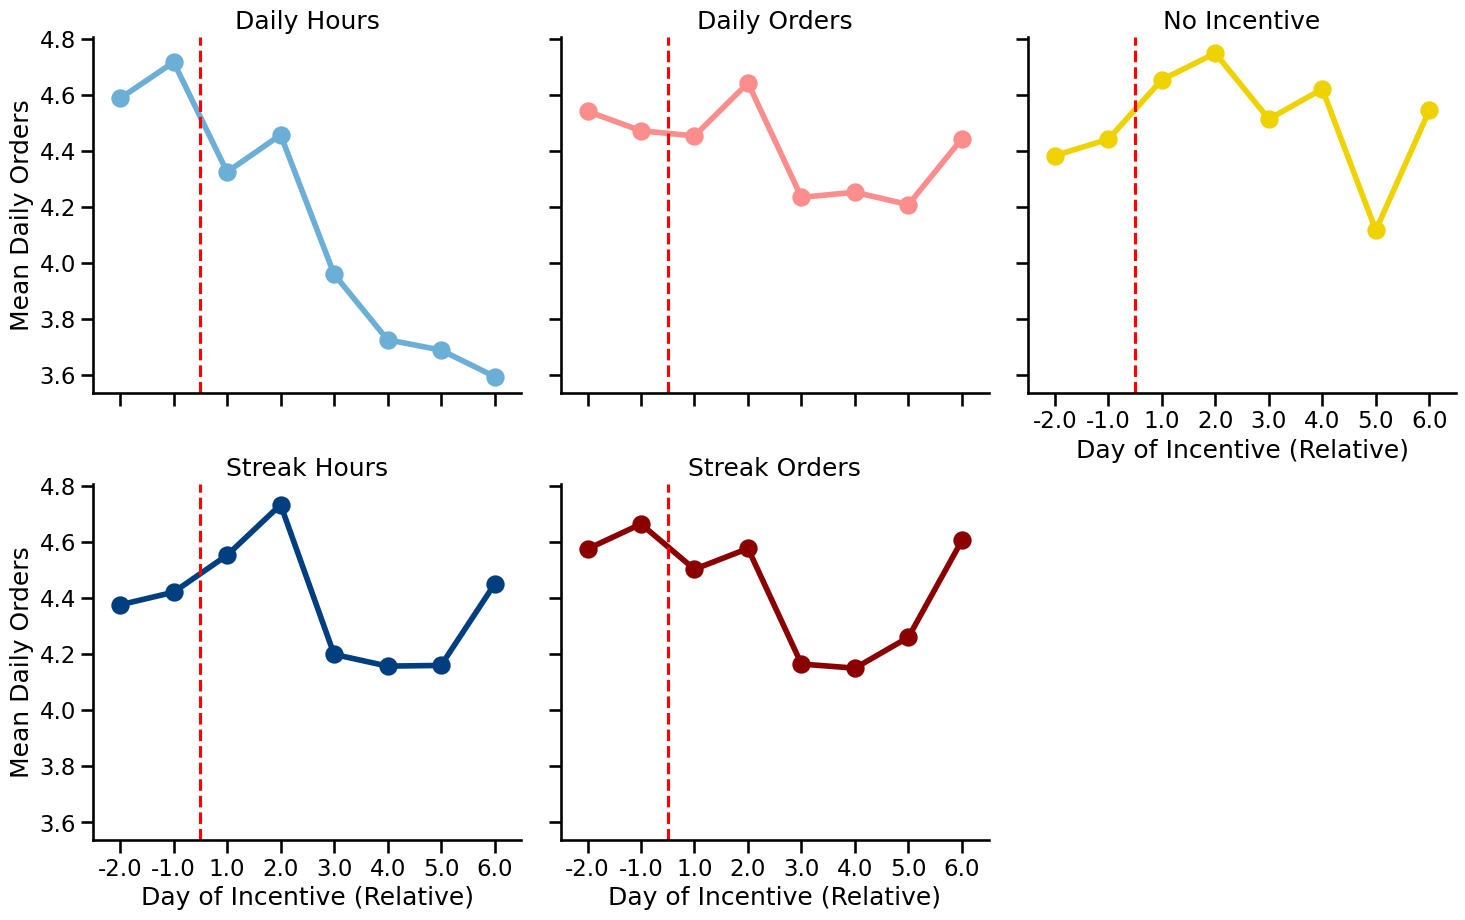

In [48]:
plt.figure(figsize=(14, 10))

g = sns.catplot(
    data=df_final_plot_hours, 
    x='day', 
    y='hours', 
    col='Incentive', 
    kind='point',
    col_wrap=3, 
    sharey=True,
    palette=INCENTIVE_COLORS,  # replaces color="#4C72B0"
    hue='Incentive',           # needed for palette to apply per facet
    legend=False               # hides the redundant legend since col titles already label them
)

for ax in g.axes.flat:
    ax.set_ylabel("Mean Daily Hours Worked")
    ax.set_xlabel("Day of Incentive (Relative)")
    ax.axvline(x=1.5, color='red', linestyle='--', label='Start')

g.set_axis_labels("Day of Incentive (Relative)", "Mean Daily Orders")
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.9)
plt.show()
